# Inference and Evaluation of Pretrained E. coli FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on E. coli metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

In [1]:
import os
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from ecoli_core_merged_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [2]:
class AttentionBlock(nn.Module):
    """Multi-head attention block with per-head diffusion of c."""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads

        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Learnable head aggregation
        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        """
        x: (B, S, d_model)
        c: (B, S, 1)
        returns: x_out (B, S, d_model), c_out (B, S, 1)
        """
        x_norm = self.layer_norm(x)

        # Get per-head attention weights: (B, H, S, S)
        attn_out, attn_weights = self.mha(
            x_norm, x_norm, x_norm,
            need_weights=True,
            average_attn_weights=False
        )
        
        x_out = attn_out + x

        # Per-head diffusion of c:
        # (B, H, S, S) @ (B, 1, S, 1) -> (B, H, S, 1)
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out


In [3]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [4]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [5]:
def load_pretrained_model(checkpoint_path, device=None):
    """
    Load a pretrained model from a checkpoint file (*_checkpoint.pth).

    Returns:
        model: FluxTransformer on `device`, in eval() mode
        config: dict
        train_losses: list[float]
        test_losses: list[float]
        data_info: dict
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    ckpt = torch.load(checkpoint_path, map_location=device)

    # Basic validation
    required_top = ["model_state_dict", "config", "train_losses", "test_losses", "data_info"]
    missing_top = [k for k in required_top if k not in ckpt]
    if missing_top:
        raise KeyError(f"Checkpoint missing keys: {missing_top}. Got keys: {list(ckpt.keys())}")

    config = ckpt["config"]

    input_token_indices = config.get("input_token_indices", None)

    if input_token_indices is None:
        raise KeyError(
            "Checkpoint is missing 'input_token_indices' in config/data_info. "
            "Cannot reconstruct FluxTransformer."
        )

    vocab_size = config.get("vocab_size", None)

    # Build model
    model = FluxTransformer(
        vocab_size=int(vocab_size),
        input_token_indices=input_token_indices,
        d_model=int(config["d_model"]),
        n_heads=int(config["n_heads"]),
        n_layers=int(config["n_layers"]),
        d_ff=int(config["d_ff"]),
        dropout=float(config["dropout"]),
    ).to(device)

    # Load weights
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    train_losses = ckpt["train_losses"]
    test_losses = ckpt["test_losses"]
    data_info = ckpt["data_info"]

    print(f"Loaded checkpoint: {checkpoint_path}")
    print(
        f"vocab_size={vocab_size}, n_injected={len(input_token_indices)}, "
        f"d_model={config['d_model']}, n_heads={config['n_heads']}, "
        f"n_layers={config['n_layers']}, d_ff={config['d_ff']}"
    )

    return model, config, train_losses, test_losses, data_info

### Plotting Functions

In [6]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [7]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [8]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (N, S, n_layers) and selected_indices are token indices

    This plots the realized flux target vs predicted realized flux for the requested token slot.
    """
    model_cpu = model.to("cpu").eval()

    # Basic sanity checks
    if len(outputs) != getattr(model_cpu, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model_cpu.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model_cpu.vocab_size or y_test.shape[1] != model_cpu.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model_cpu.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)

    with torch.no_grad():
        preds_all_layers, selected_indices = model_cpu(
            X_test.unsqueeze(-1).to("cpu"),
            output_subset=None
        )

    # Map token_idx -> its position inside selected_indices (should exist when output_subset=None)
    selected_indices_np = selected_indices.cpu().numpy()
    pos = np.where(selected_indices_np == token_idx)[0]
    if pos.size == 0:
        raise RuntimeError(
            f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
            "This should not happen when output_subset=None."
        )
    pos = int(pos[0])

    # last-layer scalar prediction for this token: (N,)
    y_pred = preds_all_layers[:, pos, -1].cpu().numpy()
    y_true = y_test[:, token_idx].cpu().numpy()

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model_cpu, "input_token_indices") and model_cpu.input_token_indices is not None:
        injected = bool((model_cpu.input_token_indices.cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

In [17]:
def plot_post_attention_real_context(
    model,
    token_names,                 # full token list, len == model.vocab_size
    X_test,                      # (N, vocab_size) token matrix (your injected-medium X_tok)
    *,
    token_indices=None,          # optional list[int] of token indices to visualize
    method="pca",
    n_components=2,
    n_samples=1000,
    perplexity=30.0,
    n_neighbors=15,
    min_dist=0.1,
    save_path=None,
    batch_size=128,
    random_state=42,
):
    device = next(model.parameters()).device
    model.eval()

    V = model.vocab_size
    if len(token_names) != V:
        raise ValueError(f"token_names length {len(token_names)} must equal model.vocab_size {V}.")

    # X_test must be (N, V)
    if not torch.is_tensor(X_test):
        X_test = torch.tensor(X_test, dtype=torch.float32)
    if X_test.dim() != 2 or X_test.size(1) != V:
        raise ValueError(f"X_test must have shape (N, {V}). Got {tuple(X_test.shape)}")

    N = min(int(n_samples), int(X_test.size(0)))

    if token_indices is None:
        token_indices = list(range(V))
    else:
        token_indices = [int(i) for i in token_indices]
        bad = [i for i in token_indices if i < 0 or i >= V]
        if bad:
            raise ValueError(f"token_indices contains out-of-range indices: {bad[:10]}")

    n_tok = len(token_indices)
    if n_tok == 0:
        raise ValueError("No tokens selected to plot (token_indices is empty).")

    all_embeddings = []
    token_id_labels = []

    with torch.no_grad():
        for i in range(0, N, batch_size):
            bs = min(batch_size, N - i)
            batch_context = X_test[i:i+bs].to(device).unsqueeze(-1)  # (B, V, 1)

            # return_embedding=True returns (x, selected_indices)
            x, _ = model(batch_context, output_subset=None, return_embedding=True)
            # x: (B, V, d_model)

            tok_x = x[:, token_indices, :]  # (B, n_tok, d_model)
            all_embeddings.append(tok_x.cpu())
            token_id_labels.append(np.tile(np.arange(n_tok), bs))

    all_embeddings = torch.cat(all_embeddings, dim=0)               # (N, n_tok, d_model)
    token_id_labels = np.concatenate(token_id_labels)              # (N*n_tok,)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()

    # Dimensionality reduction
    m = method.lower()
    if m == "pca":
        reducer = PCA(n_components=n_components)
        method_name = "PCA"
    elif m == "tsne":
        reducer = TSNE(
            n_components=n_components,
            perplexity=perplexity,
            random_state=random_state,
            init="pca",
        )
        method_name = "t-SNE"
    elif m == "umap":
        try:
            from umap import UMAP
        except ImportError as e:
            raise ImportError("UMAP not installed. Install with: pip install umap-learn") from e
        reducer = UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=random_state,
        )
        method_name = "UMAP"
    else:
        raise ValueError(f"Invalid method '{method}'. Use 'pca', 'tsne', or 'umap'.")

    embeddings_rd = reducer.fit_transform(embeddings_flat)

    # Colormap + per-token center (median)
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_tok))
    discrete_cmap = ListedColormap(colors)

    centers = []
    for local_idx in range(n_tok):
        mask = (token_id_labels == local_idx)
        if np.any(mask):
            centers.append((local_idx, np.median(embeddings_rd[mask], axis=0)))

    # Plot
    if n_components == 3:
        import mpl_toolkits.mplot3d  # noqa: F401
        fig = plt.figure(figsize=(16, 12))
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(
            embeddings_rd[:, 0], embeddings_rd[:, 1], embeddings_rd[:, 2],
            c=token_id_labels, cmap=discrete_cmap, alpha=0.15, s=7, edgecolors="none"
        )
        ax.set_title(f"Post-Attention Embeddings\n({N} contexts, {method_name})", fontsize=16)
        ax.set_xlabel(f"{method_name} 1", fontsize=12)
        ax.set_ylabel(f"{method_name} 2", fontsize=12)
        ax.set_zlabel(f"{method_name} 3", fontsize=12)
        ax.grid(alpha=0.2)

    elif n_components == 2:
        plt.figure(figsize=(16, 12))
        plt.scatter(
            embeddings_rd[:, 0], embeddings_rd[:, 1],
            c=token_id_labels, cmap=discrete_cmap, alpha=0.2, s=10, edgecolors="none"
        )

        for local_idx, center in centers:
            global_idx = token_indices[local_idx]
            name = token_names[global_idx].replace("_flux", "")
            plt.scatter(
                center[0], center[1],
                s=30, marker="o",
                color=colors[local_idx],
                edgecolor="black", linewidth=0.5
            )
            plt.annotate(
                name, center,
                xytext=(5, 5), textcoords="offset points",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
            )

        plt.title(f"Post-Attention Embeddings\n({N} contexts, {method_name})", fontsize=16)
        plt.xlabel(f"{method_name} 1", fontsize=12)
        plt.ylabel(f"{method_name} 2", fontsize=12)
        plt.grid(alpha=0.1)

    else:
        raise ValueError("n_components must be 2 or 3")

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Plot saved to {save_path}")
    else:
        plt.show()
        plt.close()


In [52]:
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import to_hex

def compute_flux_correlation_clusters(
    data_path=DATA_PATH,
    *,
    outputs=None,            # list[str] of 95 *_flux column names (recommended: pass `outputs` from load_data/model)
    n_clusters=12,
    method="pearson",        # "pearson" | "spearman" | "kendall" (pandas supports these)
    use_abs=True,            # cluster on |corr| to group strong positive/negative coupling together
):
    """
    Computes correlation-based clusters over output flux columns in `data_path`.

    Returns:
      labels: np.ndarray shape (V,) aligned with `outputs` order
      cluster_colors: dict[int -> hex_color]
      output_cols: list[str] used for correlations (same as outputs if provided)
    """
    df = pd.read_csv(data_path)

    if outputs is None:
        output_cols = [c for c in df.columns if c.endswith("_flux")]
    else:
        output_cols = list(outputs)

    if len(output_cols) == 0:
        raise ValueError("No output flux columns found (expected columns ending with '_flux').")

    for c in output_cols:
        if c not in df.columns:
            raise ValueError(f"Missing required output column in data: {c}")

    V = len(output_cols)
    n_clusters = int(n_clusters)
    n_clusters = max(1, min(n_clusters, V))

    # correlation matrix
    corr = df[output_cols].corr(method=method).to_numpy(dtype=np.float64)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)

    # ensure diagonal is 1.0
    np.fill_diagonal(corr, 1.0)

    sim = np.abs(corr) if use_abs else corr
    sim = np.clip(sim, -1.0, 1.0)

    # distance for clustering
    dist = 1.0 - sim
    np.fill_diagonal(dist, 0.0)

    if n_clusters == 1:
        labels = np.zeros(V, dtype=np.int64)
    else:
        try:
            clusterer = AgglomerativeClustering(
                n_clusters=n_clusters,
                metric="precomputed",
                linkage="average",
            )
        except TypeError:
            clusterer = AgglomerativeClustering(
                n_clusters=n_clusters,
                affinity="precomputed",
                linkage="average",
            )
        labels = clusterer.fit_predict(dist).astype(np.int64)

    # colors
    cmap = plt.get_cmap("turbo" if n_clusters <= 10 else "hsv") # tab20, turbo
    denom = max(1, n_clusters - 1)
    cluster_colors = {k: to_hex(cmap(k / denom)) for k in range(n_clusters)}

    return labels, cluster_colors, output_cols

In [44]:
def plot_post_attention_grouped_tsne(
    model,
    outputs,                 # full token list, len == vocab_size
    X_test,                  # (N, V) or (N, V, 1)
    token_indices=None,      # optional list[int] of tokens to plot; default = all tokens
    n_samples=1000,
    perplexity=30.0,
    save_path=None,
    batch_size=128,
    annotate=False,          # default False (otherwise 95+ labels is unreadable)
    reducer="tsne",          # "tsne" (default) or "umap"
    n_neighbors=50,          # UMAP only
    min_dist=0.5,            # UMAP only
    coloring="pathway",      # "pathway" (original groups) or "corr" (correlation clusters)
    corr_data_path=DATA_PATH,
    corr_n_clusters=12,
    corr_method="pearson",
    corr_use_abs=True,
):
    """
    Grouped t-SNE/UMAP of post-layer token embeddings (the x stream) under real contexts.

    Works with FluxTransformer:
      - model(..., return_embedding=True) returns (x, selected_indices)
      - x is the token embedding after attention+FF layers, shape (B, S, d_model)
      - selected_indices are token ids corresponding to x positions, shape (S,)

    X_test is expected to already be token-space context (medium constraints injected into token slots):
      - shape (N, V) or (N, V, 1) where V == model.vocab_size.
    """

    device = next(model.parameters()).device
    model.eval()

    V = int(model.vocab_size)
    if len(outputs) != V:
        raise ValueError(f"len(outputs)={len(outputs)} but model.vocab_size={V}. Must match.")

    reducer = str(reducer).lower()
    if reducer not in ("tsne", "umap"):
        raise ValueError(f"reducer must be 'tsne' or 'umap'; got {reducer!r}")

    coloring = str(coloring).lower()
    if coloring not in ("pathway", "corr"):
        raise ValueError(f"coloring must be 'pathway' or 'corr'; got {coloring!r}")

    # choose tokens to plot
    if token_indices is None:
        token_indices = list(range(V))
    else:
        token_indices = [int(i) for i in token_indices]
        bad = [i for i in token_indices if i < 0 or i >= V]
        if bad:
            raise ValueError(f"token_indices has out-of-range entries: {bad[:10]} (V={V})")

    # pathway coloring setup (based on cleaned token names)
    clean_tokens = [t.replace("_flux", "") for t in outputs]

    group_colors = {
        'Ethanol Fermentation': "#FB737E",
        'Acetate Production':   "#FEABA5",
        'Lactate Production':   "#FFDAC1",
        'Formate Production':   "#F9AA61",
        'Glycolysis':           "#6CC070",
        'Gluconeogenesis':      "#7CECCA",
        'PP Pathway':           "#C7F0BD",
        'TCA Cycle':            "#237DE4",
        'Glyoxylate Shunt':     "#63B4FF",
        'Anaplerotic':          "#B0DEF4",
        'OxPhos':               "#A4409F",
        'ATP Maintenance':      "#C77DFF",
        'Anaerobic Respiration':"#BBACD7",
        'Nitrogen Uptake':      "#E2C000",
        'Glu/Gln Synthesis':    "#FFF1A8",
        'Transport & EX':       "#B0B0B0",
        'Biomass':              "#483954",
        'Other':                "#999999",
    }

    pathway_groups = {
        'Ethanol Fermentation': ['ACALD', 'ALCD2x', 'ETOHt2r', 'EX_etoh_e', 'ACALDt', 'EX_acald_e'],
        'Acetate Production':   ['PTAr', 'ACKr', 'ACt2r', 'EX_ac_e'],
        'Lactate Production':   ['LDH_D', 'D_LACt2', 'EX_lac__D_e'],
        'Formate Production':   ['PFL', 'FORt2', 'FORti', 'EX_for_e'],

        'Glycolysis':           ['GLCpts', 'FRUpts2', 'PGI', 'PFK', 'FBA', 'TPI', 'GAPD', 'PGK', 'PGM', 'ENO', 'PYK',
                                 'EX_glc__D_e', 'EX_fru_e'],
        'Gluconeogenesis':      ['FBP', 'PPS'],
        'PP Pathway':           ['G6PDH2r', 'PGL', 'GND', 'RPE', 'RPI', 'TKT1', 'TKT2', 'TALA'],

        'TCA Cycle':            ['PDH', 'CS', 'ACONTa', 'ACONTb', 'ICDHyr', 'AKGDH', 'SUCOAS', 'SUCDi', 'FUM', 'MDH',
                                 'FUMt2_2', 'MALt2_2', 'SUCCt2_2', 'SUCCt3', 'AKGt2r',
                                 'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e'],
        'Glyoxylate Shunt':     ['ICL', 'MALS'],
        'Anaplerotic':          ['PPC', 'PPCK', 'ME1', 'ME2'],

        'OxPhos':               ['CYTBD', 'ATPS4r', 'NADH16', 'THD2', 'NADTRHD'],
        'ATP Maintenance':      ['ATPM', 'ADK1'],
        'Anaerobic Respiration':['FRD7'],

        'Nitrogen Uptake':      ['GLNabc', 'GLUt2r', 'NH4t', 'EX_nh4_e', 'EX_gln__L_e', 'EX_glu__L_e'],
        'Glu/Gln Synthesis':    ['GLNS', 'GLUDy', 'GLUN', 'GLUSy'],

        'Transport & EX':       ['CO2t', 'H2Ot', 'O2t', 'PIt2r', 'PYRt2',
                                 'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_o2_e', 'EX_pi_e', 'EX_pyr_e'],

        'Biomass':              ['Biomass_Ecoli_core'],
    }

    # map token -> group
    flux_to_group = {}
    for group, keys in pathway_groups.items():
        for k in keys:
            flux_to_group[k] = group

    token_group = ["Other"] * V
    for tid in range(V):
        name = clean_tokens[tid]
        g = "Other"
        for key, grp in flux_to_group.items():
            if key in name:
                g = grp
                break
        token_group[tid] = g

    legend_title = "Metabolic Pathways"
    title_suffix = "Grouped by Pathway"

    # Optional correlation-cluster coloring (overrides token_group and group_colors)
    if coloring == "corr":
        labels, cluster_colors, output_cols = compute_flux_correlation_clusters(
            corr_data_path,
            outputs=outputs,  # align clusters to model output order
            n_clusters=corr_n_clusters,
            method=corr_method,
            use_abs=corr_use_abs,
        )
        token_group = [f"Cluster {int(labels[tid])}" for tid in range(V)]
        group_colors = {f"Cluster {k}": v for k, v in cluster_colors.items()}
        legend_title = "Correlation clusters"
        title_suffix = f"Correlation Clusters ({corr_method}, {'|corr|' if corr_use_abs else 'corr'})"

    # collect embeddings for requested tokens
    n_samples = min(int(n_samples), len(X_test))
    token_indices_tensor = torch.tensor(token_indices, dtype=torch.long, device=device)

    all_embeddings = []
    all_token_ids = []

    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            bs = min(batch_size, n_samples - i)

            batch_raw = X_test[i:i+bs]
            if not torch.is_tensor(batch_raw):
                batch_raw = torch.tensor(batch_raw, dtype=torch.float32)

            batch_raw = batch_raw.to(device)

            if batch_raw.dim() == 2:
                if batch_raw.size(1) != V:
                    raise ValueError(f"X_test has {batch_raw.size(1)} columns, expected V={V}.")
                batch_context = batch_raw.unsqueeze(-1)  # (B, V, 1)
            elif batch_raw.dim() == 3:
                if batch_raw.size(1) != V or batch_raw.size(2) != 1:
                    raise ValueError(f"X_test must be (N,V) or (N,V,1); got {tuple(batch_raw.shape)}")
                batch_context = batch_raw
            else:
                raise ValueError(f"X_test must be (N,V) or (N,V,1); got {tuple(batch_raw.shape)}")

            # Ask model for embeddings
            x, selected = model(batch_context, output_subset=token_indices_tensor, return_embedding=True)

            # Filter embeddings to EXACTLY the requested token_indices
            pos = torch.searchsorted(selected, token_indices_tensor)
            if not torch.all(selected[pos] == token_indices_tensor):
                missing = token_indices_tensor[~(selected[pos] == token_indices_tensor)].tolist()
                raise RuntimeError(f"Some requested tokens were not returned by model selection: {missing[:10]}")

            x_keep = x[:, pos, :]  # (B, n_keep, d_model)

            all_embeddings.append(x_keep.detach().cpu())
            all_token_ids.append(np.tile(np.array(token_indices, dtype=np.int64), bs))

    all_embeddings = torch.cat(all_embeddings, dim=0)                 # (n_samples, n_keep, d_model)
    token_ids_flat = np.concatenate(all_token_ids, axis=0)            # (n_samples*n_keep,)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()

    n_points = embeddings_flat.shape[0]

    if reducer == "tsne":
        if perplexity >= n_points:
            new_perp = max(5.0, min(30.0, (n_points - 1) / 3.0))
            print(f"[plot_post_attention_grouped_tsne] Adjusting perplexity {perplexity} -> {new_perp:.2f} (n_points={n_points})")
            perplexity = float(new_perp)

        tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca")
        emb2d = tsne.fit_transform(embeddings_flat)
        title_method = "t-SNE"
        xlab = "t-SNE 1"
        ylab = "t-SNE 2"
    else:
        try:
            from umap import UMAP
        except ImportError as e:
            raise ImportError("UMAP requested but 'umap-learn' is not installed. Install with: pip install umap-learn") from e

        umap = UMAP(
            n_components=2,
            n_neighbors=int(n_neighbors),
            min_dist=float(min_dist),
            random_state=42,
        )
        emb2d = umap.fit_transform(embeddings_flat)
        title_method = "UMAP"
        xlab = "UMAP 1"
        ylab = "UMAP 2"

    point_colors = [group_colors[token_group[int(tid)]] for tid in token_ids_flat]

    plt.figure(figsize=(16, 12))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=point_colors, alpha=0.20, s=10, edgecolors="none")

    # Legend: only groups present in this plot
    present_groups = []
    present_set = set(token_group[int(tid)] for tid in set(token_ids_flat.tolist()))

    if coloring == "corr":
        # Keep cluster order numeric
        def _cluster_key(name):
            # "Cluster k"
            try:
                return int(str(name).split()[-1])
            except Exception:
                return 10**9
        for g in sorted(group_colors.keys(), key=_cluster_key):
            if g in present_set:
                present_groups.append(g)
    else:
        for g in group_colors.keys():
            if g in present_set:
                present_groups.append(g)

    legend_patches = [mpatches.Patch(color=group_colors[g], label=g) for g in present_groups]
    plt.legend(handles=legend_patches, title=legend_title, bbox_to_anchor=(1.05, 1), loc="upper left")

    if annotate:
        for tid in token_indices:
            mask = (token_ids_flat == tid)
            if np.any(mask):
                center = np.median(emb2d[mask], axis=0)
                plt.annotate(
                    clean_tokens[tid],
                    center,
                    xytext=(5, 5),
                    textcoords="offset points",
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
                )

    plt.title(
        f"Post-layer Token Embeddings ({title_method}), {title_suffix}\n(n_contexts={n_samples}, n_tokens={len(token_indices)})",
        fontsize=16,
    )
    plt.xlabel(xlab, fontsize=12)
    plt.ylabel(ylab, fontsize=12)
    plt.grid(alpha=0.1)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Grouped {title_method} plot saved to {save_path}")
    else:
        plt.show()
        plt.close()

In [33]:
def plot_pre_attention_embeddings_tsne(
    model,
    token_names,
    perplexity=30.0,
    save_path=None,
    annotate=True
):
    """
    t-SNE of the learned token embedding table BEFORE any attention/updates.

    - Always uses ALL tokens: token_ids = 0..(vocab_size-1)
    - token_names must be aligned with token indices (same order used in training)
    """
    model.eval()
    device = next(model.parameters()).device

    n_tokens = int(model.vocab_size)
    if len(token_names) != n_tokens:
        raise ValueError(
            f"len(token_names)={len(token_names)} must equal model.vocab_size={n_tokens}."
        )

    # t-SNE constraint: perplexity < n_tokens
    if perplexity >= n_tokens:
        perplexity = max(5.0, float(n_tokens - 1))
        print(f"[plot_pre_attention_embeddings_tsne] Adjusted perplexity to {perplexity} (must be < n_tokens).")

    with torch.no_grad():
        token_ids = torch.arange(n_tokens, device=device)
        emb = model.input_embedding(token_ids).detach().cpu().numpy()  # (n_tokens, d_model)

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init="pca")
    emb2d = tsne.fit_transform(emb)

    # Color by token index
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_tokens))

    plt.figure(figsize=(14, 10))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=colors, s=60, alpha=0.9)

    if annotate:
        for i, name in enumerate(token_names):
            plt.annotate(
                name.replace("_flux", ""),
                (emb2d[i, 0], emb2d[i, 1]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
            )

    plt.title("t-SNE of Token Embeddings (Pre-attention)", fontsize=16)
    plt.xlabel("t-SNE 1", fontsize=12)
    plt.ylabel("t-SNE 2", fontsize=12)
    plt.grid(alpha=0.2)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        plt.close()
        print(f"Pre-attention embedding visualization saved to {save_path}")
    else:
        plt.show()
        plt.close()

In [31]:
def animate_real_context_tsne(
    model,
    token_names,                 # e.g. `outputs` (len == model.vocab_size)
    X_test,                      # (N, V) token-matrix from new load_data
    *,
    token_indices=None,          # optional subset; default = all tokens
    n_samples=1000,
    perplexity=30.0,
    n_iter=200,
    step=1,
    gif_path=None,
    batch_size=128,
    target_radius=0.95,
    fixed_lim=1.0,
    interval_ms=50,
    fps=20,
    seed=42,
    alpha=0.2,
    point_size=10,
):
    # openTSNE imports
    try:
        from openTSNE import TSNEEmbedding, affinity, initialization
    except ImportError as e:
        raise ImportError("openTSNE is required for this animation. Install: pip install openTSNE") from e

    device = next(model.parameters()).device
    model.eval()

    V = int(model.vocab_size)
    if len(token_names) != V:
        raise ValueError(f"len(token_names)={len(token_names)} must equal model.vocab_size={V}.")

    # choose tokens
    if token_indices is None:
        token_indices = list(range(V))
    else:
        token_indices = [int(i) for i in token_indices]
        if len(token_indices) == 0:
            raise ValueError("token_indices is empty.")
        if min(token_indices) < 0 or max(token_indices) >= V:
            raise ValueError("token_indices contains out-of-range indices.")

    n_tokens = len(token_indices)

    # choose samples
    n_samples = min(int(n_samples), int(len(X_test)))
    if n_samples <= 0:
        raise ValueError("n_samples must be >= 1.")

    # Collect post-layer token embeddings
    all_embeddings = []
    point_labels = []  # 0..n_tokens-1 per point

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            bs = min(batch_size, n_samples - start)

            batch_raw = X_test[start:start + bs]
            if not torch.is_tensor(batch_raw):
                batch_raw = torch.tensor(batch_raw, dtype=torch.float32)

            batch_raw = batch_raw.to(device)

            # Expect (B, V) or (B, V, 1)
            if batch_raw.dim() == 2:
                if batch_raw.size(1) != V:
                    raise ValueError(
                        f"X_test must have shape (N, V) with V={V}. Got (B, {batch_raw.size(1)}). "
                        "Pass the token-matrix returned by load_data (medium already injected)."
                    )
                batch_context = batch_raw.unsqueeze(-1)  # (B, V, 1)
            elif batch_raw.dim() == 3:
                if batch_raw.size(1) != V or batch_raw.size(2) != 1:
                    raise ValueError(f"If 3D, X_test must be (N, V, 1). Got {tuple(batch_raw.shape)}.")
                batch_context = batch_raw
            else:
                raise ValueError(f"X_test must be 2D or 3D, got {tuple(batch_raw.shape)}")

            # return_embedding=True returns post-layer x and selected_indices
            x, _ = model(batch_context, output_subset=None, return_embedding=True)  # x: (B, V, d_model)

            x_sel = x[:, token_indices, :]  # (B, n_tokens, d_model)
            all_embeddings.append(x_sel.detach().cpu())

            # label points by token slot within this subset (0..n_tokens-1)
            point_labels.append(np.tile(np.arange(n_tokens, dtype=np.int32), bs))

    all_embeddings = torch.cat(all_embeddings, dim=0)  # (n_samples, n_tokens, d_model)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()  # (n_samples*n_tokens, d_model)
    point_labels = np.concatenate(point_labels)  # (n_samples*n_tokens,)

    # openTSNE setup
    affinities = affinity.PerplexityBasedNN(
        embeddings_flat,
        perplexity=float(perplexity),
        metric="euclidean",
        n_jobs=-1,
        random_state=seed,
    )
    init = initialization.pca(embeddings_flat, n_components=2, random_state=seed)
    emb = TSNEEmbedding(init, affinities)

    # Optimize + collect frames
    embedding_history = []
    iteration_numbers = []

    def maybe_store(it_idx):
        if (it_idx % step == 0) or (it_idx == n_iter - 1):
            embedding_history.append(np.array(emb).copy())
            iteration_numbers.append(it_idx + 1)

    # A simple 4-phase exaggeration schedule
    p1 = min(40, n_iter)
    p2 = min(90, n_iter)
    p3 = min(130, n_iter)

    for it in range(0, p1):
        emb.optimize(n_iter=1, exaggeration=10.0, inplace=True)
        maybe_store(it)
    for it in range(p1, p2):
        emb.optimize(n_iter=1, exaggeration=6.0, inplace=True)
        maybe_store(it)
    for it in range(p2, p3):
        emb.optimize(n_iter=1, exaggeration=2.5, inplace=True)
        maybe_store(it)
    for it in range(p3, n_iter):
        emb.optimize(n_iter=1, exaggeration=1.0, inplace=True)
        maybe_store(it)

    print(f"Total frames collected: {len(embedding_history)} (step={step})")

    # Normalize frames to fixed view box
    def normalize_xy(xy: np.ndarray) -> np.ndarray:
        xy = xy.astype(np.float64, copy=False)
        xy = xy - xy.mean(axis=0, keepdims=True)

        r = np.sqrt(xy[:, 0] ** 2 + xy[:, 1] ** 2)
        r_q = np.quantile(r, 0.995)
        if not np.isfinite(r_q) or r_q < 1e-12:
            r_q = 1.0

        desired = target_radius * fixed_lim
        xy = xy * (desired / r_q)

        max_abs = np.max(np.abs(xy))
        if np.isfinite(max_abs) and max_abs > fixed_lim:
            xy = xy * (fixed_lim / max_abs) * 0.999

        return xy.astype(np.float32)

    normalized_history = [normalize_xy(xy) for xy in embedding_history]

    # Animate
    fig, ax = plt.subplots(figsize=(16, 12))

    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_tokens))
    cmap = ListedColormap(colors)

    first = normalized_history[0]
    scat = ax.scatter(
        first[:, 0], first[:, 1],
        c=point_labels,
        cmap=cmap,
        alpha=float(alpha),
        s=float(point_size),
        edgecolors="none",
        vmin=0, vmax=n_tokens - 1
    )

    iter_text = ax.text(
        0.02, 0.95, "", transform=ax.transAxes, fontsize=14,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_xlim(-fixed_lim, fixed_lim)
    ax.set_ylim(-fixed_lim, fixed_lim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.1)
    ax.set_title(f"openTSNE optimization (post-layer token embeddings)\n{n_samples} contexts × {n_tokens} tokens")

    def update(frame_idx):
        xy = normalized_history[frame_idx]
        scat.set_offsets(xy)
        iter_text.set_text(f"Iteration: {iteration_numbers[frame_idx]}/{n_iter}")
        return scat, iter_text

    ani = FuncAnimation(fig, update, frames=len(normalized_history), interval=interval_ms, blit=False)

    if gif_path:
        os.makedirs(os.path.dirname(gif_path), exist_ok=True)
        ani.save(gif_path, writer=PillowWriter(fps=fps), dpi=100)
        print(f"Animation saved to {gif_path}")

    plt.close(fig)
    return ani

### Load model

In [9]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
#model_name = "ecoli_core_d128_h8_l3_ff512"
model_name = "ecoli_core_merged_d128_h8_l3_ff640"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

C:\Users\truok\AppData\Local\Temp\ipykernel_4336\140046750.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=device)


Loaded checkpoint: ./models/ecoli_core_merged_d128_h8_l3_ff640/ecoli_core_merged_d128_h8_l3_ff640_checkpoint.pth
vocab_size=95, n_injected=20, d_model=128, n_heads=8, n_layers=3, d_ff=640

Total number of parameters: 709,537

Data information:
Dataset: ./data/2025-07-15_full_training_data_98066_samples.csv
Training samples: 78452
Test samples: 19614


### Load data

In [42]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/2025-07-15_full_training_data_98066_samples.csv"

X, y, input_cols, outputs, input_token_indices, out_indices = load_data(data_info['dataset'])
#X, y, input_cols, outputs_ordered, K, out_indices = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 98066 samples from ./data/2025-07-15_full_training_data_98066_samples.csv
Number of medium inputs: 20
Number of flux tokens:   95
Medium constraints are injected into these token indices (in outputs order):
[27, 25, 32, 37, 19, 21, 38, 26, 33, 23, 20, 24, 28, 29, 22, 30, 31, 34, 35, 36]
Training samples: 78452
Test samples: 19614


In [26]:
def compare_inputs_to_flux_cols(csv_path, input_cols, row=0):
    df = pd.read_csv(csv_path)

    # Match training behavior: missing inputs -> 0
    df[input_cols] = df[input_cols].fillna(0)

    flux_cols = [f"{c}_flux" for c in input_cols]
    missing = [c for c in flux_cols if c not in df.columns]
    if missing:
        raise ValueError("Missing *_flux columns in CSV:\n" + "\n".join(missing))

    inp = df.loc[row, input_cols].to_numpy(dtype=np.float32)
    flx = df.loc[row, flux_cols].to_numpy(dtype=np.float32)

    out = pd.DataFrame({
        "input_rxn": input_cols,
        "input_value": inp,
        "flux_rxn": flux_cols,
        "flux_value": flx,
        "diff": inp - flx,
        "abs_diff": np.abs(inp - flx),
    })
    return out

csv_path = data_info["dataset"]  # or DATA_PATH
check_df = compare_inputs_to_flux_cols(csv_path, input_cols, row=0)

display(check_df[["input_rxn", "input_value", "flux_rxn", "flux_value", "diff", "abs_diff"]])

print("Max abs diff:", float(check_df["abs_diff"].max()))

,input_rxn,input_value,flux_rxn,flux_value,diff,abs_diff
0,EX_glc__D_e,7.540000,EX_glc__D_e_flux,-2.209293e+00,9.749293,9.749293
1,EX_fru_e,0.000000,EX_fru_e_flux,0.000000e+00,0.000000,0.000000
2,EX_lac__D_e,0.000000,EX_lac__D_e_flux,0.000000e+00,0.000000,0.000000
3,EX_pyr_e,0.100000,EX_pyr_e_flux,7.974107e-16,0.100000,0.100000
4,EX_ac_e,0.000000,EX_ac_e_flux,2.855952e+00,-2.855952,2.855952
5,EX_akg_e,9.650000,EX_akg_e_flux,-1.702775e-02,9.667027,9.667027
6,EX_succ_e,0.000000,EX_succ_e_flux,0.000000e+00,0.000000,0.000000
7,EX_fum_e,0.000000,EX_fum_e_flux,0.000000e+00,0.000000,0.000000
8,EX_mal__L_e,0.000000,EX_mal__L_e_flux,0.000000e+00,0.000000,0.000000
9,EX_etoh_e,0.130000,EX_etoh_e_flux,-1.300000e-01,0.260000,0.260000


Max abs diff: 45.6626091003418


In [13]:
model.eval()

FluxTransformer(
  (input_embedding): Embedding(95, 128)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((129,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=129, out_features=640, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=640, out_features=129, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

### Plot Results

In [14]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

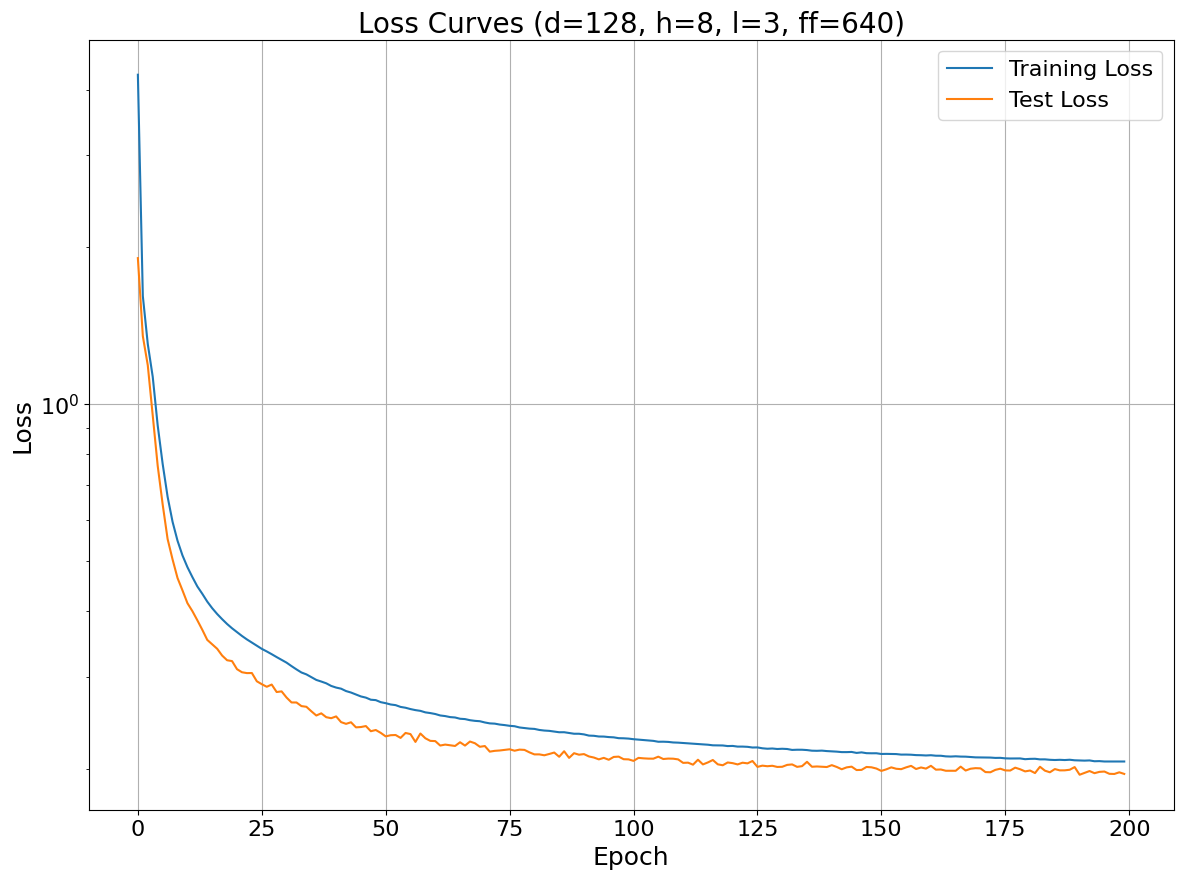

In [15]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
    )

Biomass_Ecoli_core_flux:
------------------------------------------------------------
Biomass_Ecoli_core_flux token index: 12
injected medium slot: False
y_true range: 4.0233742765849456e-05 to 2.6499929428100586
y_pred range: -0.08706974983215332 to 2.5108909606933594


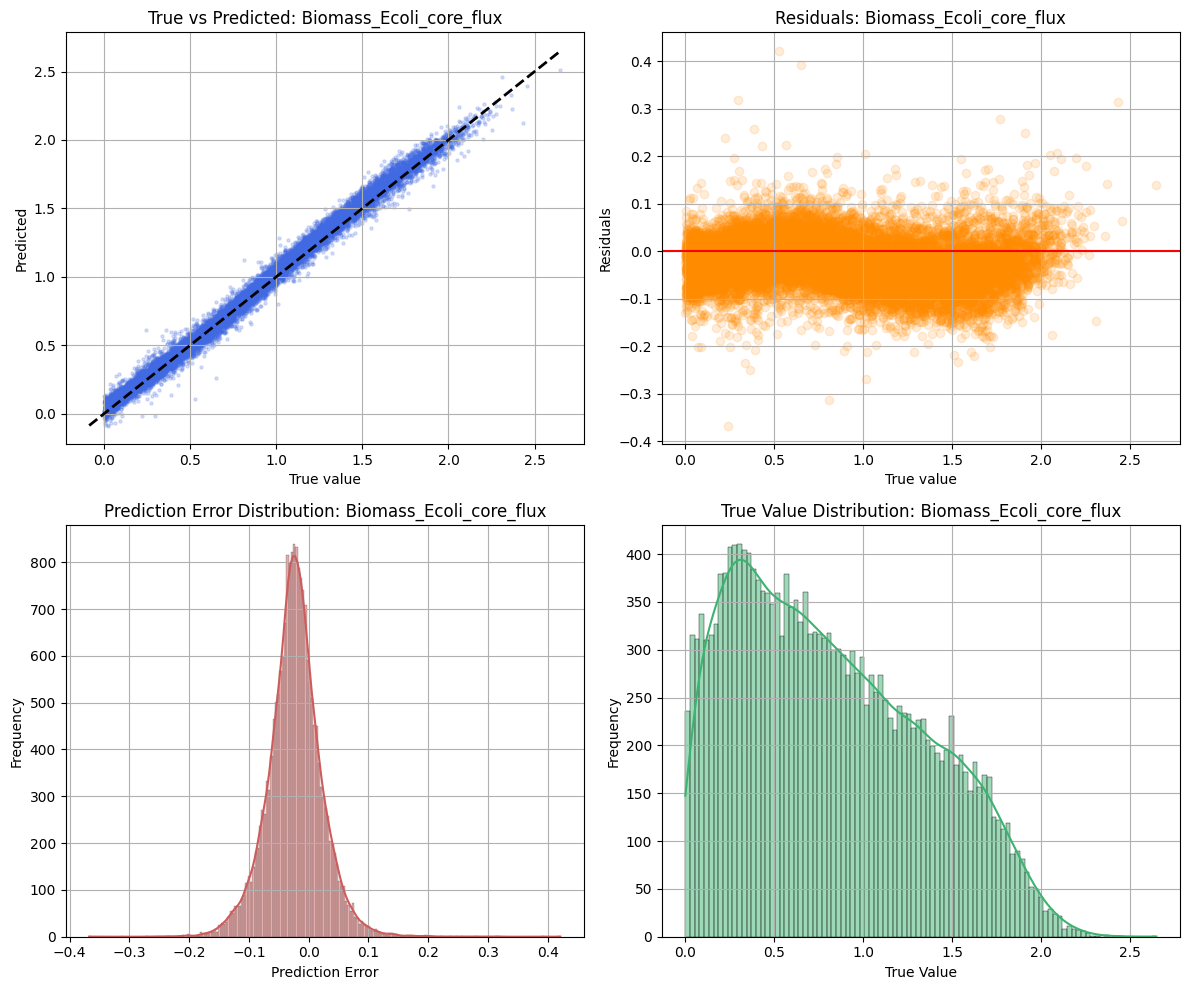

GLUDy_flux:
------------------------------------------------------------
GLUDy_flux token index: 52
injected medium slot: False
y_true range: -9.924531936645508 to 49.97012710571289
y_pred range: -9.89370346069336 to 24.28571891784668


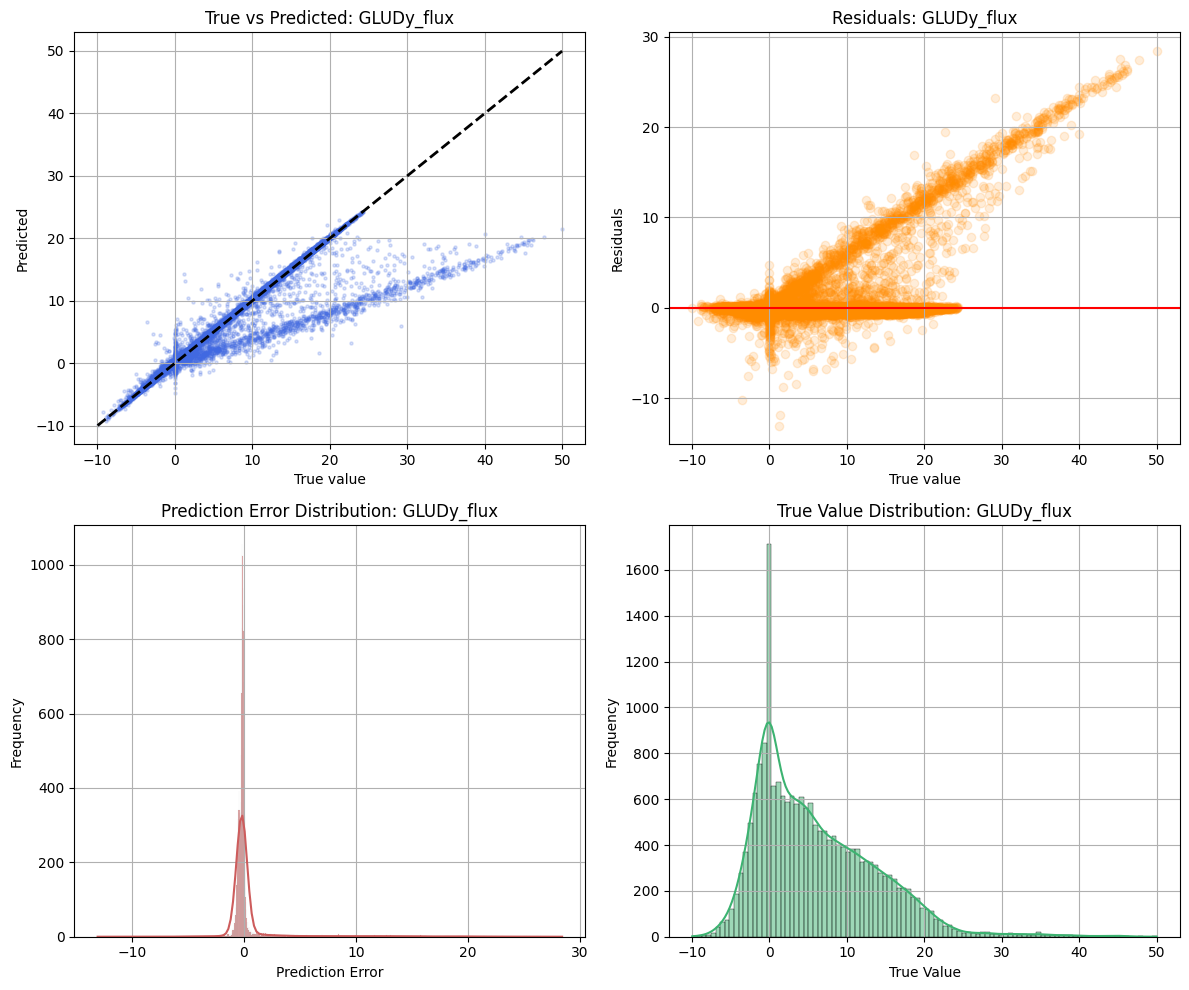

H2Ot_flux:
------------------------------------------------------------
H2Ot_flux token index: 57
injected medium slot: False
y_true range: -60.683223724365234 to 27.899232864379883
y_pred range: -57.30390548706055 to 26.77841567993164


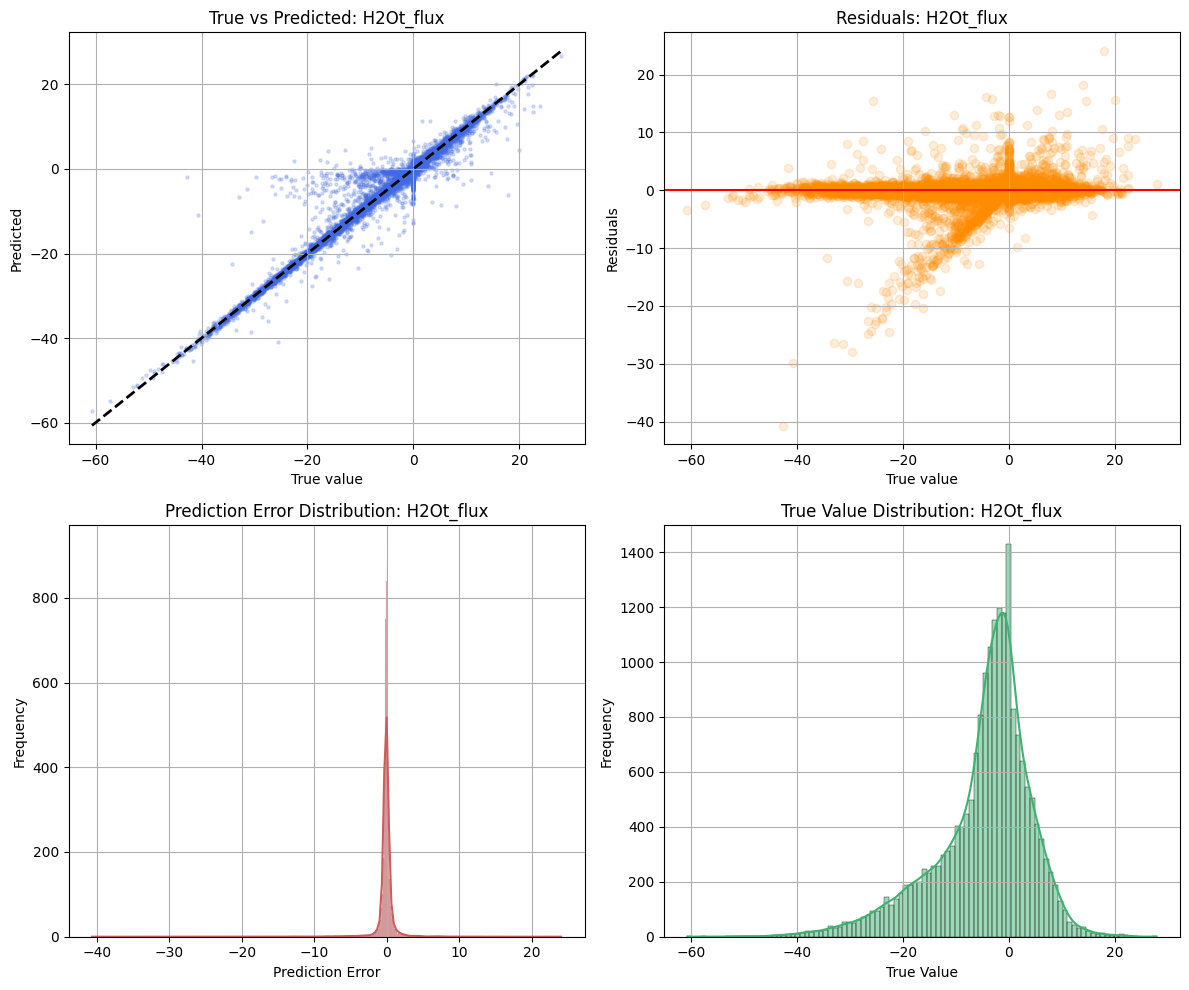

SUCCt3_flux:
------------------------------------------------------------
SUCCt3_flux token index: 87
injected medium slot: False
y_true range: -1.0446964474053466e-12 to 16.208797454833984
y_pred range: -0.20277798175811768 to 13.10302734375


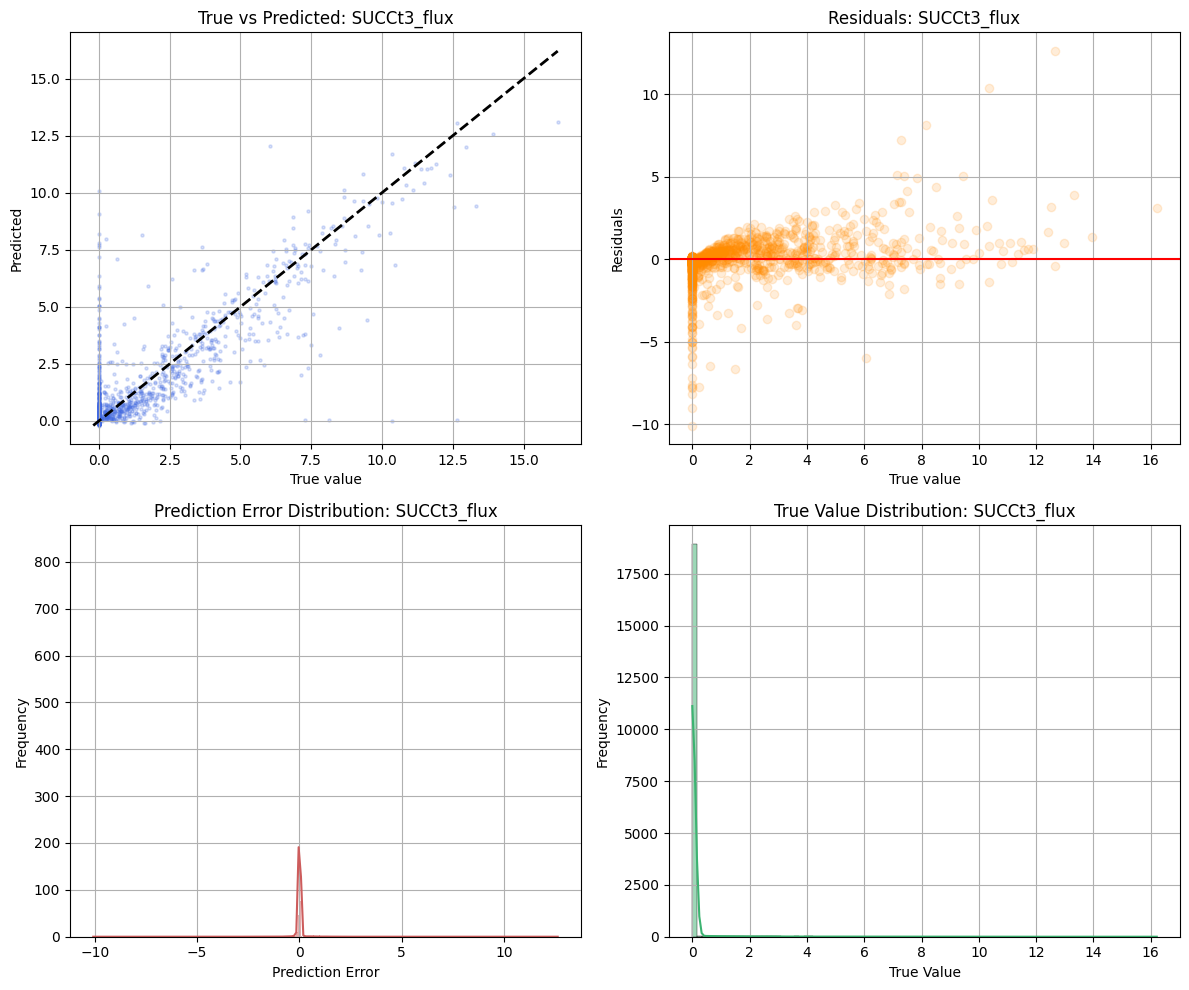

GLUN_flux:
------------------------------------------------------------
GLUN_flux token index: 53
injected medium slot: False
y_true range: -9.76646352359627e-15 to 28.625926971435547
y_pred range: -0.3584250211715698 to 28.796478271484375


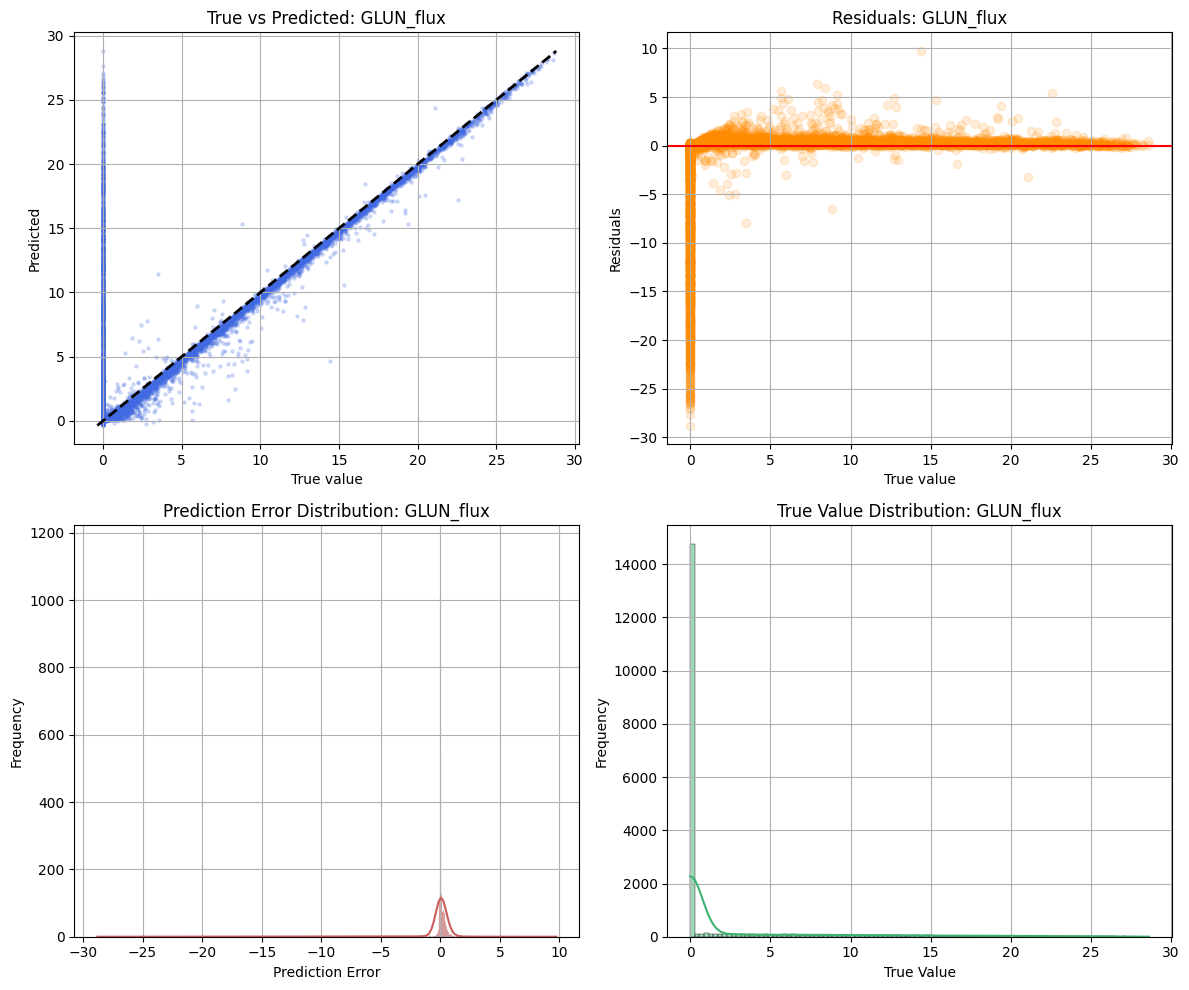

PGM_flux:
------------------------------------------------------------
PGM_flux token index: 76
injected medium slot: False
y_true range: -33.516029357910156 to 8.295674324035645
y_pred range: -34.04668045043945 to 8.394796371459961


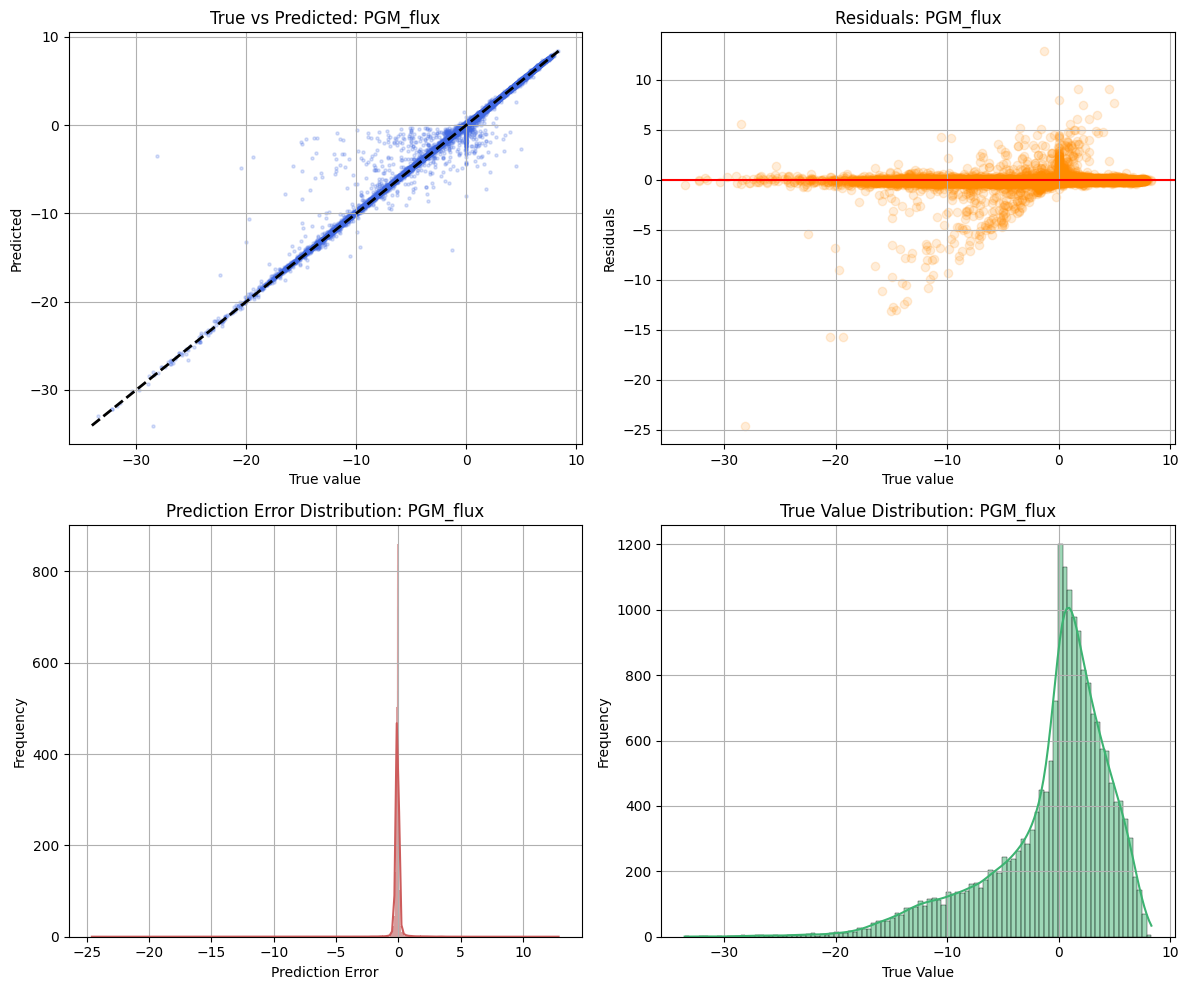

EX_glc__D_e_flux:
------------------------------------------------------------
EX_glc__D_e_flux token index: 27
injected medium slot: True
y_true range: -10.0 to 0.0
y_pred range: -10.170114517211914 to 0.1422736644744873


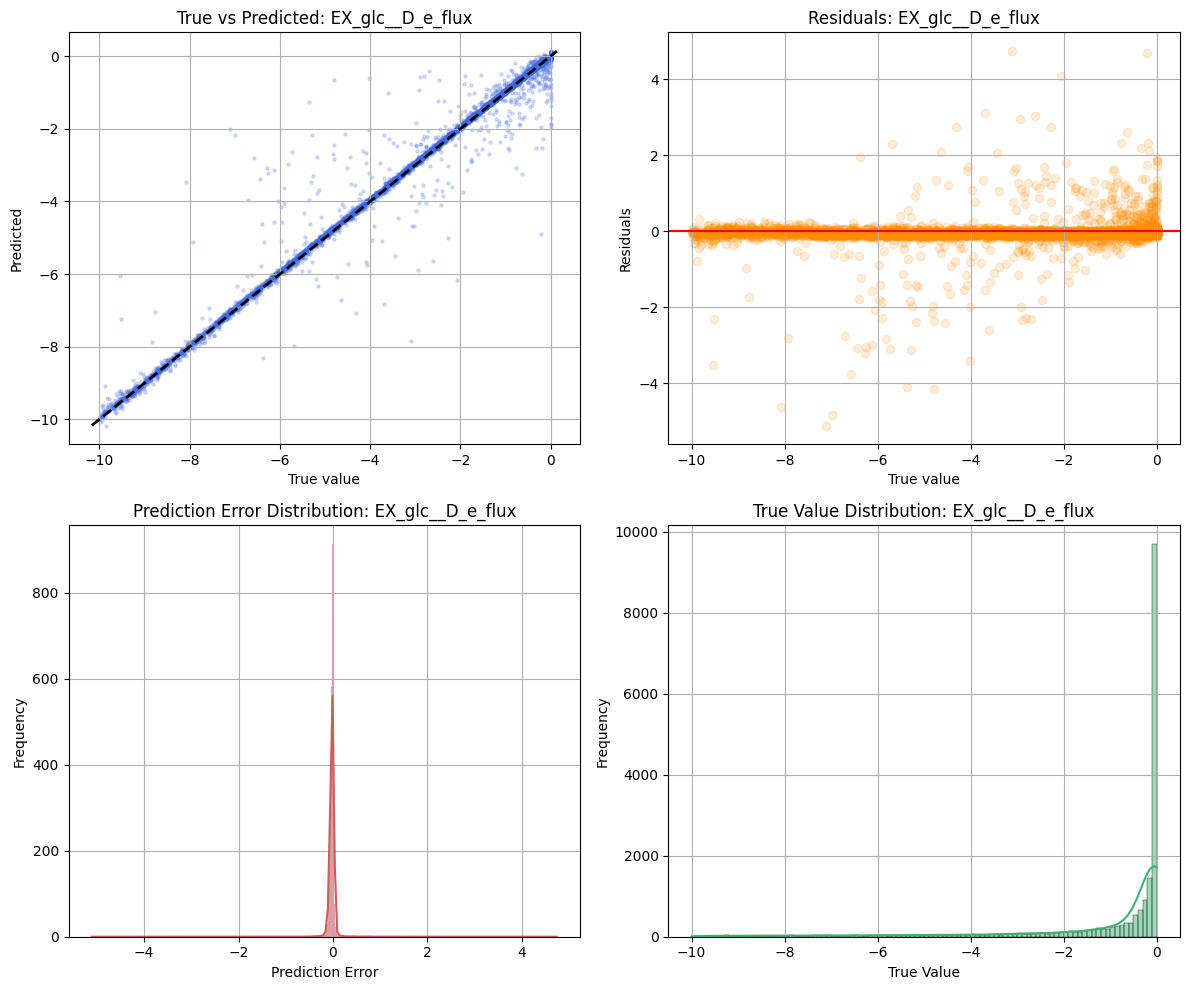

In [16]:
diagnostics_to_plot = ['Biomass_Ecoli_core_flux', 'GLUDy_flux', 'H2Ot_flux', 'SUCCt3_flux', 'GLUN_flux', 'PGM_flux', 'EX_glc__D_e_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)

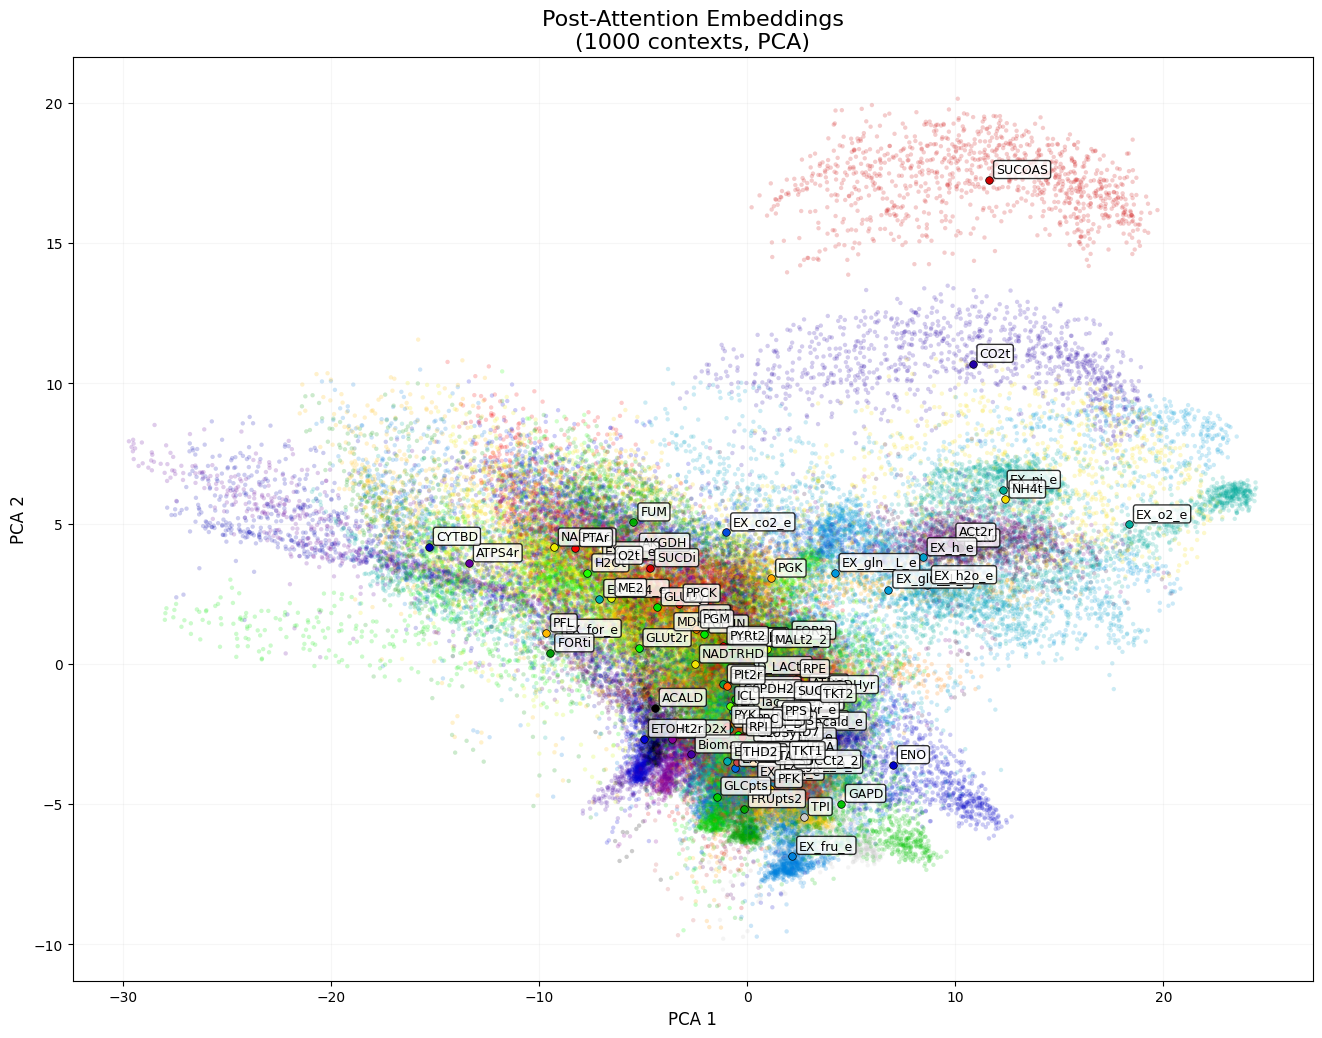

In [18]:
plot_post_attention_real_context(
    model,
    token_names=outputs,
    X_test=X_test,
    method="pca",
    n_components=2,
    n_samples=1000,
)

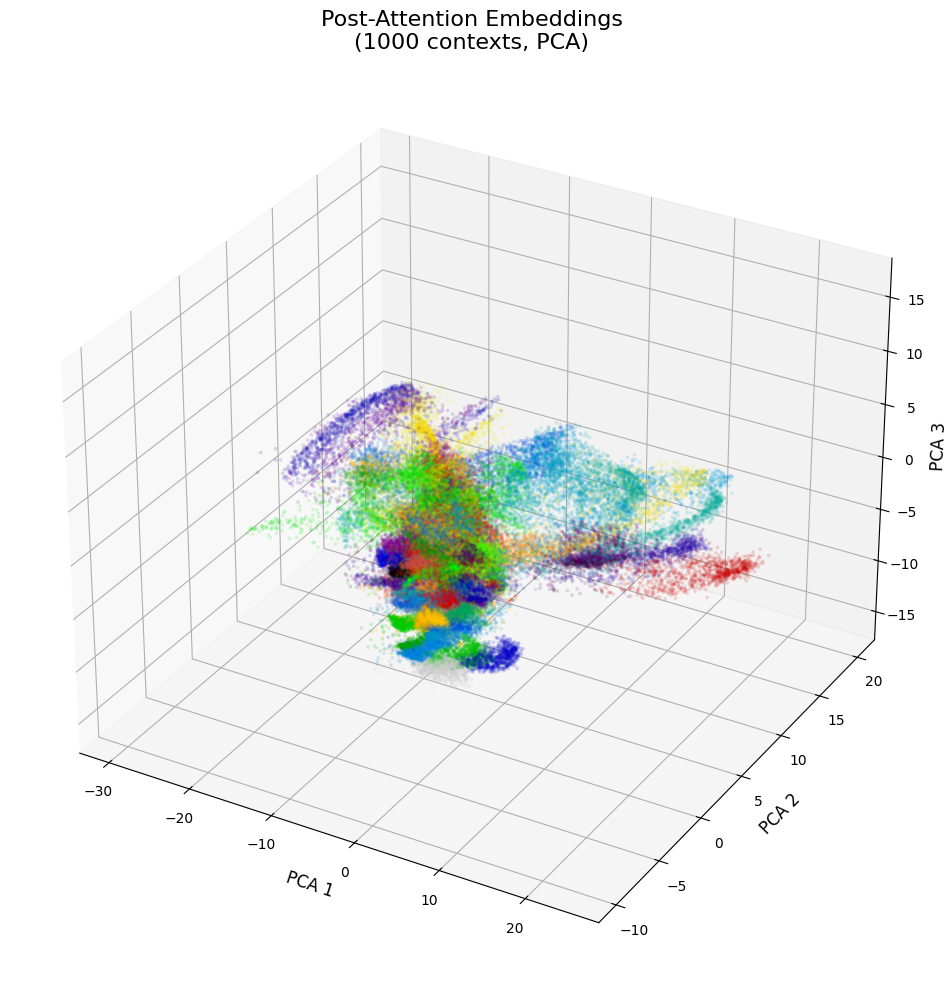

In [19]:
plot_post_attention_real_context(
    model,
    token_names=outputs,
    X_test=X_test,
    method="pca",
    n_components=3,
    n_samples=1000,
)

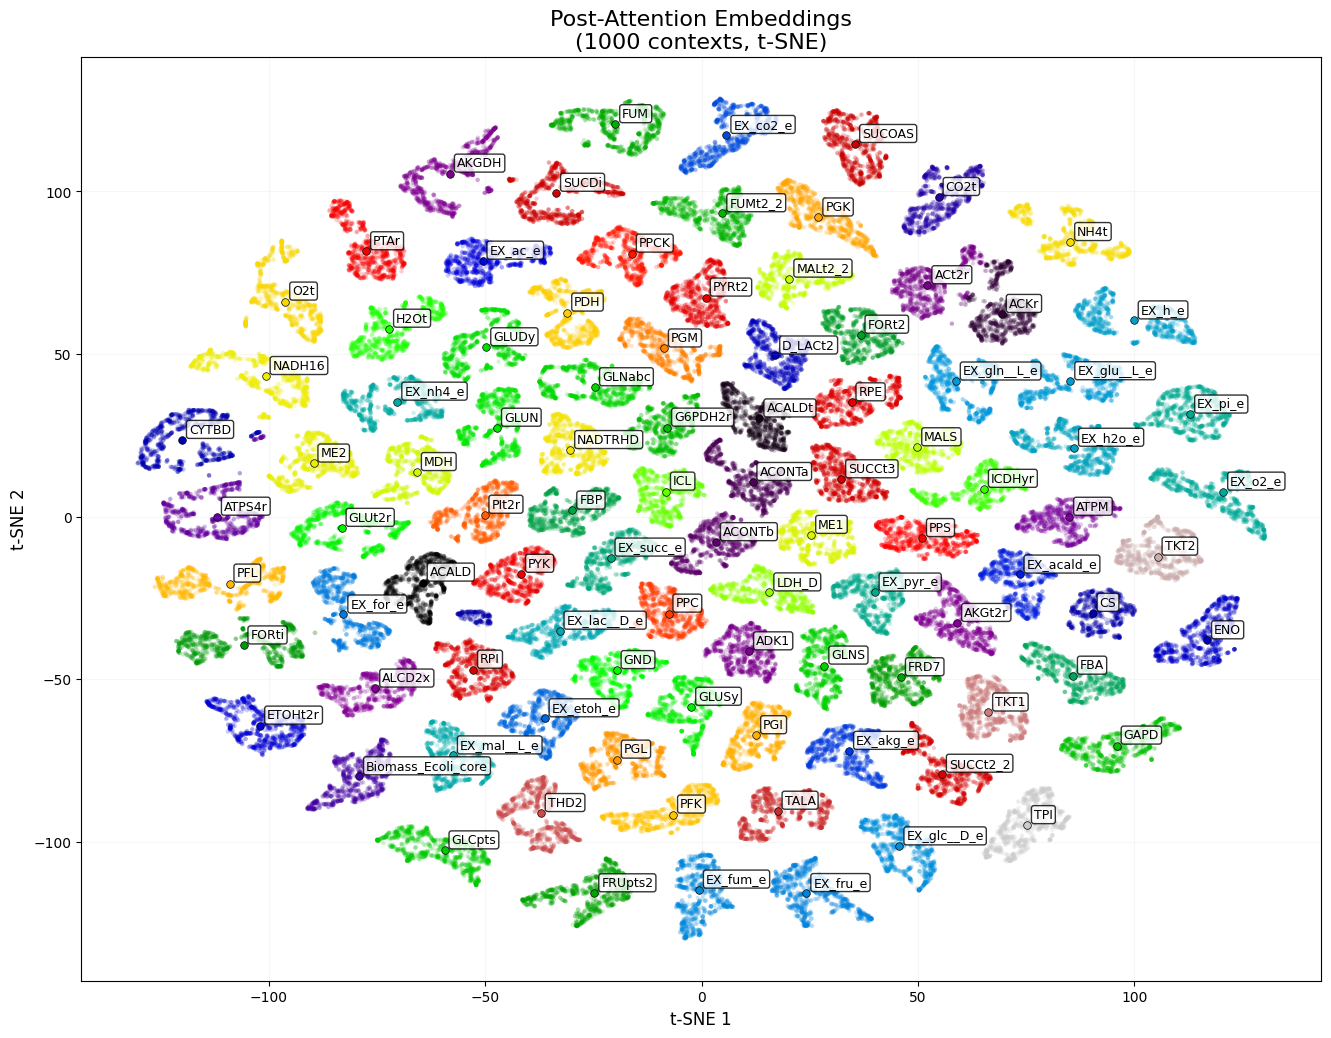

In [20]:
plot_post_attention_real_context(
    model,
    token_names=outputs,
    X_test=X_test,
    method="tsne",
    n_components=2,
    n_samples=1000,
    perplexity=30.0
)

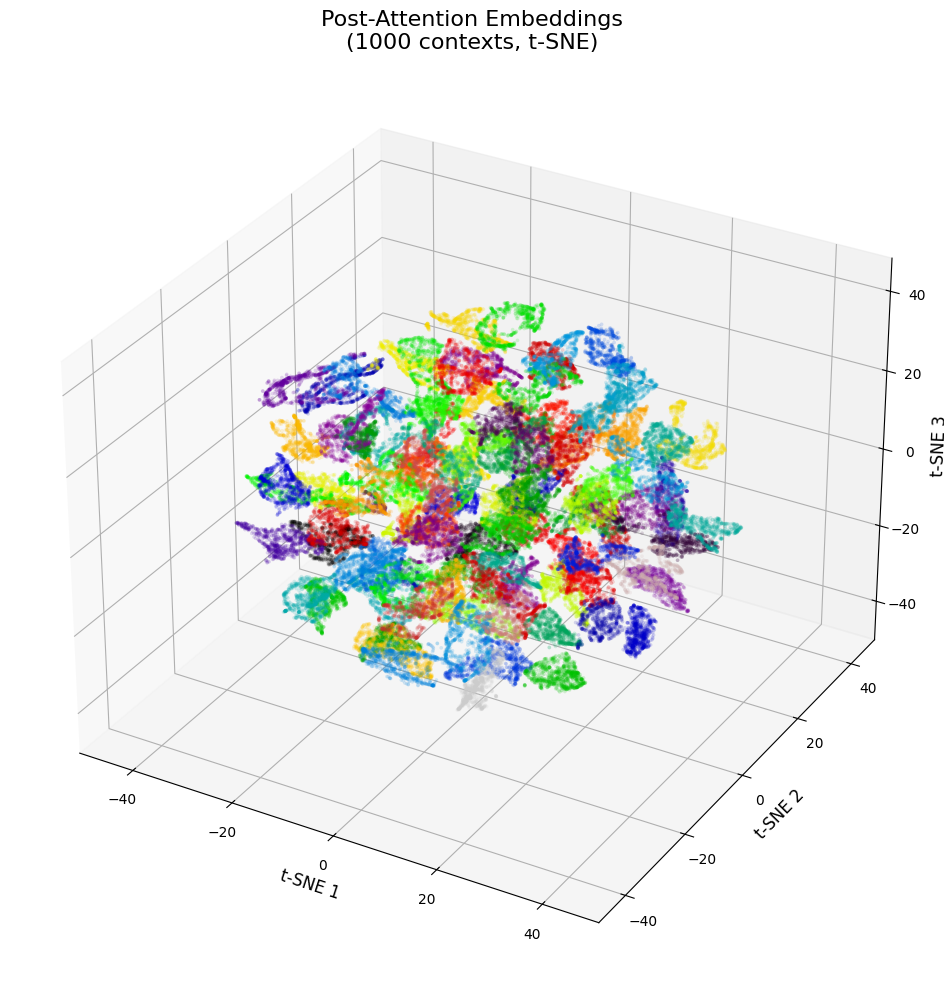

In [21]:
plot_post_attention_real_context(
    model,
    token_names=outputs,
    X_test=X_test,
    method="tsne",
    n_components=3,
    n_samples=1000,
    perplexity=40.0
)

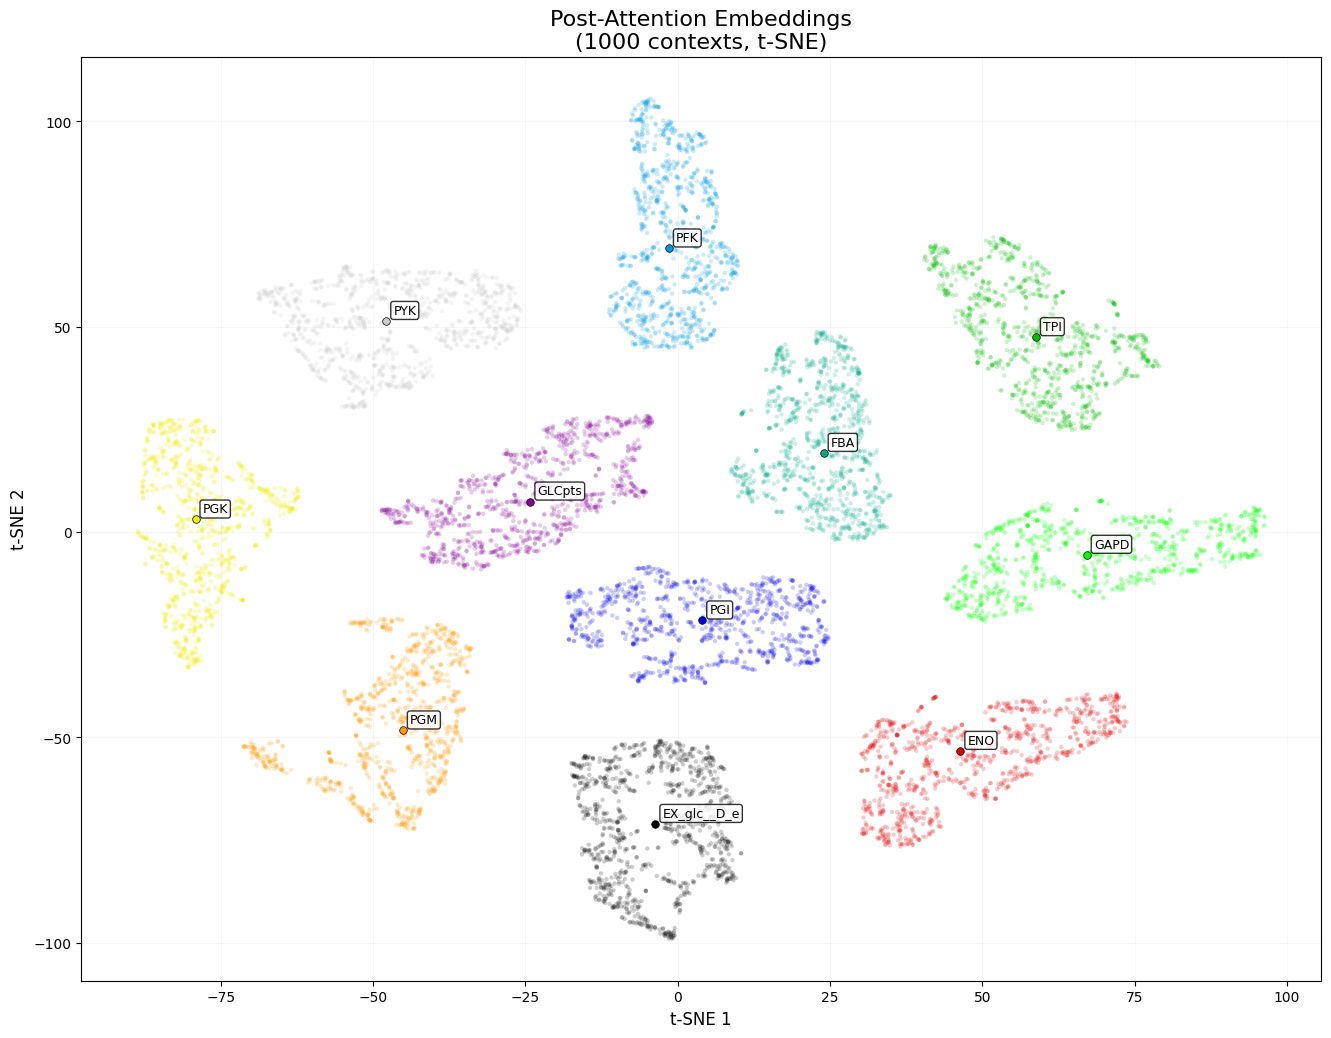

In [22]:
# Use only subset of tokens
glycolysis_tokens = [
    "EX_glc__D_e_flux", "GLCpts_flux",
    "PGI_flux", "PFK_flux", "FBA_flux", "TPI_flux",
    "GAPD_flux", "PGK_flux", "PGM_flux", "ENO_flux", "PYK_flux",
]
idxs = [outputs.index(t) for t in glycolysis_tokens if t in outputs]

'''
tca_tokens = [
    "PDH_flux", "CS_flux", "ACONTa_flux", "ACONTb_flux", "ICDHyr_flux",
    "AKGDH_flux", "SUCOAS_flux", "SUCDi_flux", "FUM_flux", "MDH_flux",
    "SUCCt2_2_flux", "SUCCt3_flux",
]
idxs = [outputs.index(t) for t in tca_tokens if t in outputs]

ppp_tokens = [
    "G6PDH2r_flux", "PGL_flux", "GND_flux", "RPE_flux", "RPI_flux",
    "TKT1_flux", "TKT2_flux", "TALA_flux",
]
idxs = [outputs.index(t) for t in ppp_tokens if t in outputs]

fermentation_tokens = [
    "PFL_flux", "FORt2_flux", "FORti_flux", "EX_for_e_flux",
    "LDH_D_flux", "D_LACt2_flux", "EX_lac__D_e_flux",
    "ACALD_flux", "ACALDt_flux", "ALCD2x_flux", "ETOHt2r_flux", "EX_etoh_e_flux",
    "PTAr_flux", "ACKr_flux", "ACt2r_flux", "EX_ac_e_flux",
]
idxs = [outputs.index(t) for t in fermentation_tokens if t in outputs]

resp_tokens = [
    "NADH16_flux", "NADTRHD_flux", "THD2_flux", "CYTBD_flux",
    "ATPS4r_flux", "ATPM_flux", "O2t_flux",
    "EX_o2_e_flux", "EX_co2_e_flux", "CO2t_flux",
]
idxs = [outputs.index(t) for t in resp_tokens if t in outputs]
'''
plot_post_attention_real_context(
    model, 
    outputs, 
    X_test, 
    token_indices=idxs, 
    method="tsne", 
    n_components=2,
    n_samples=1000,
    perplexity=30.0
)

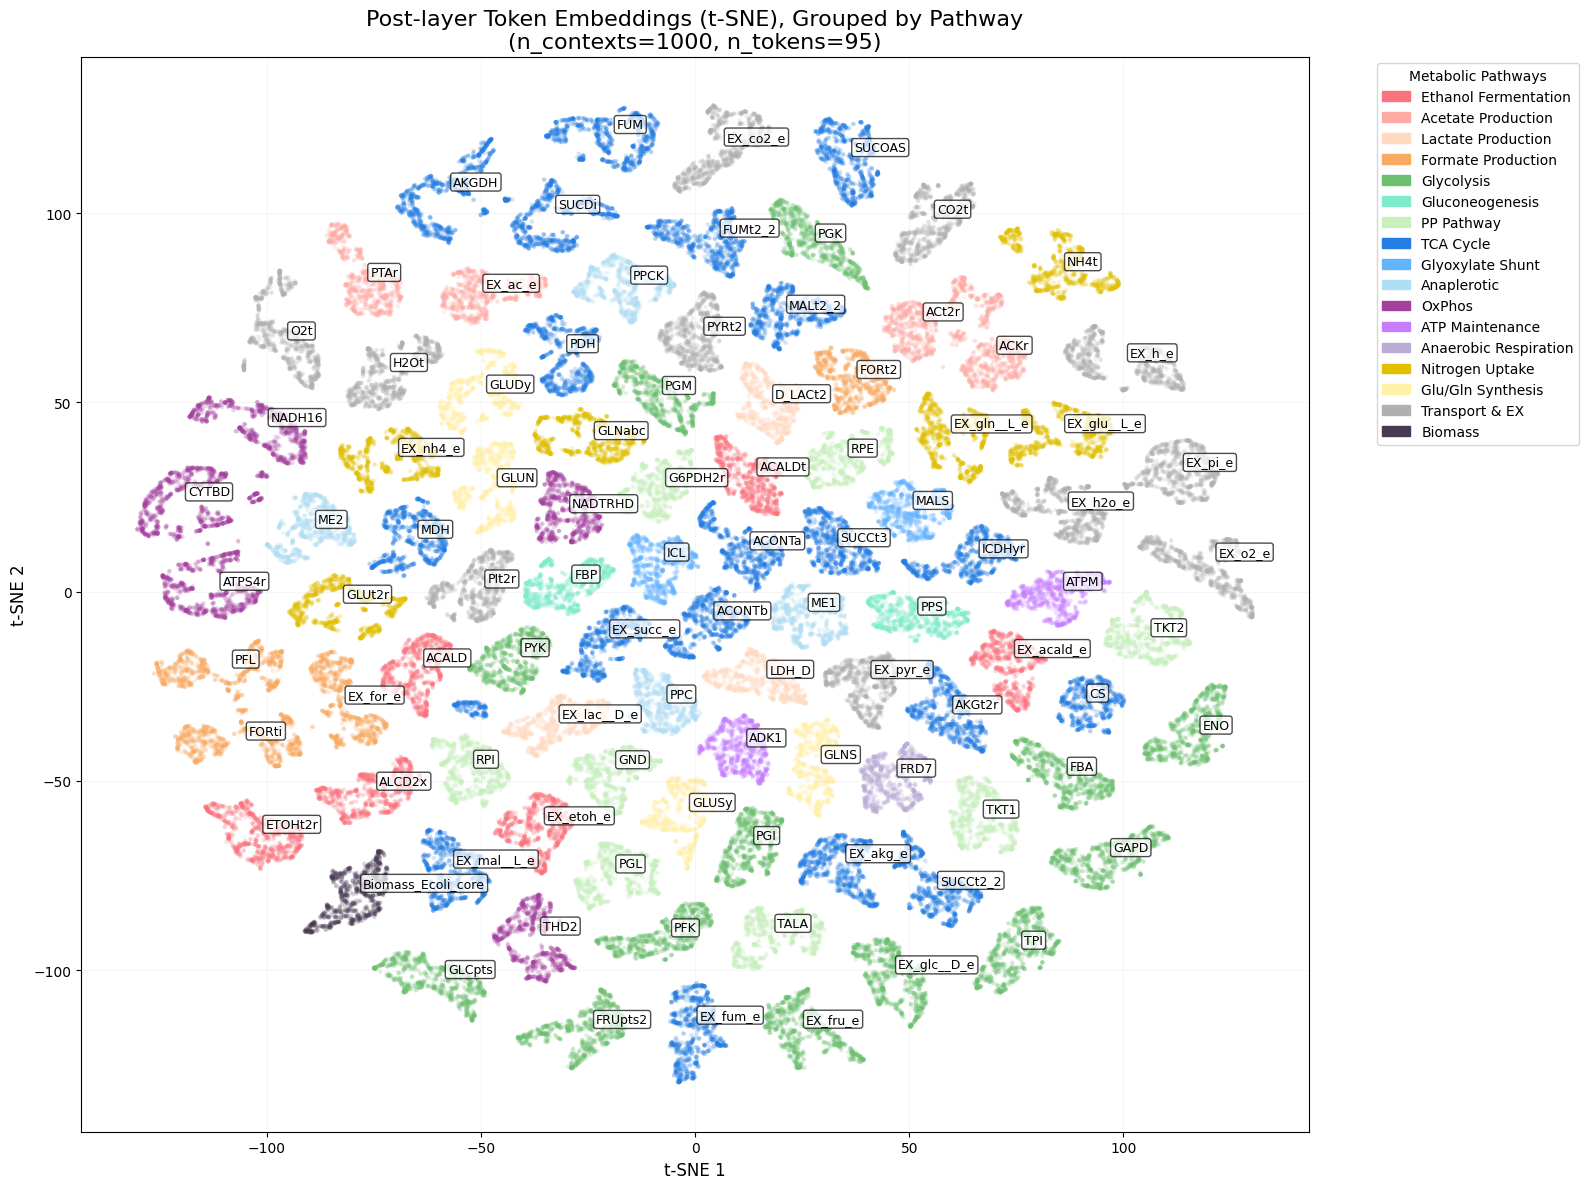

In [45]:
plot_post_attention_grouped_tsne(
    model,
    outputs,
    X_test,
    n_samples=1000,
    perplexity=30.0,
    token_indices=None,   # all tokens
    annotate=True
)

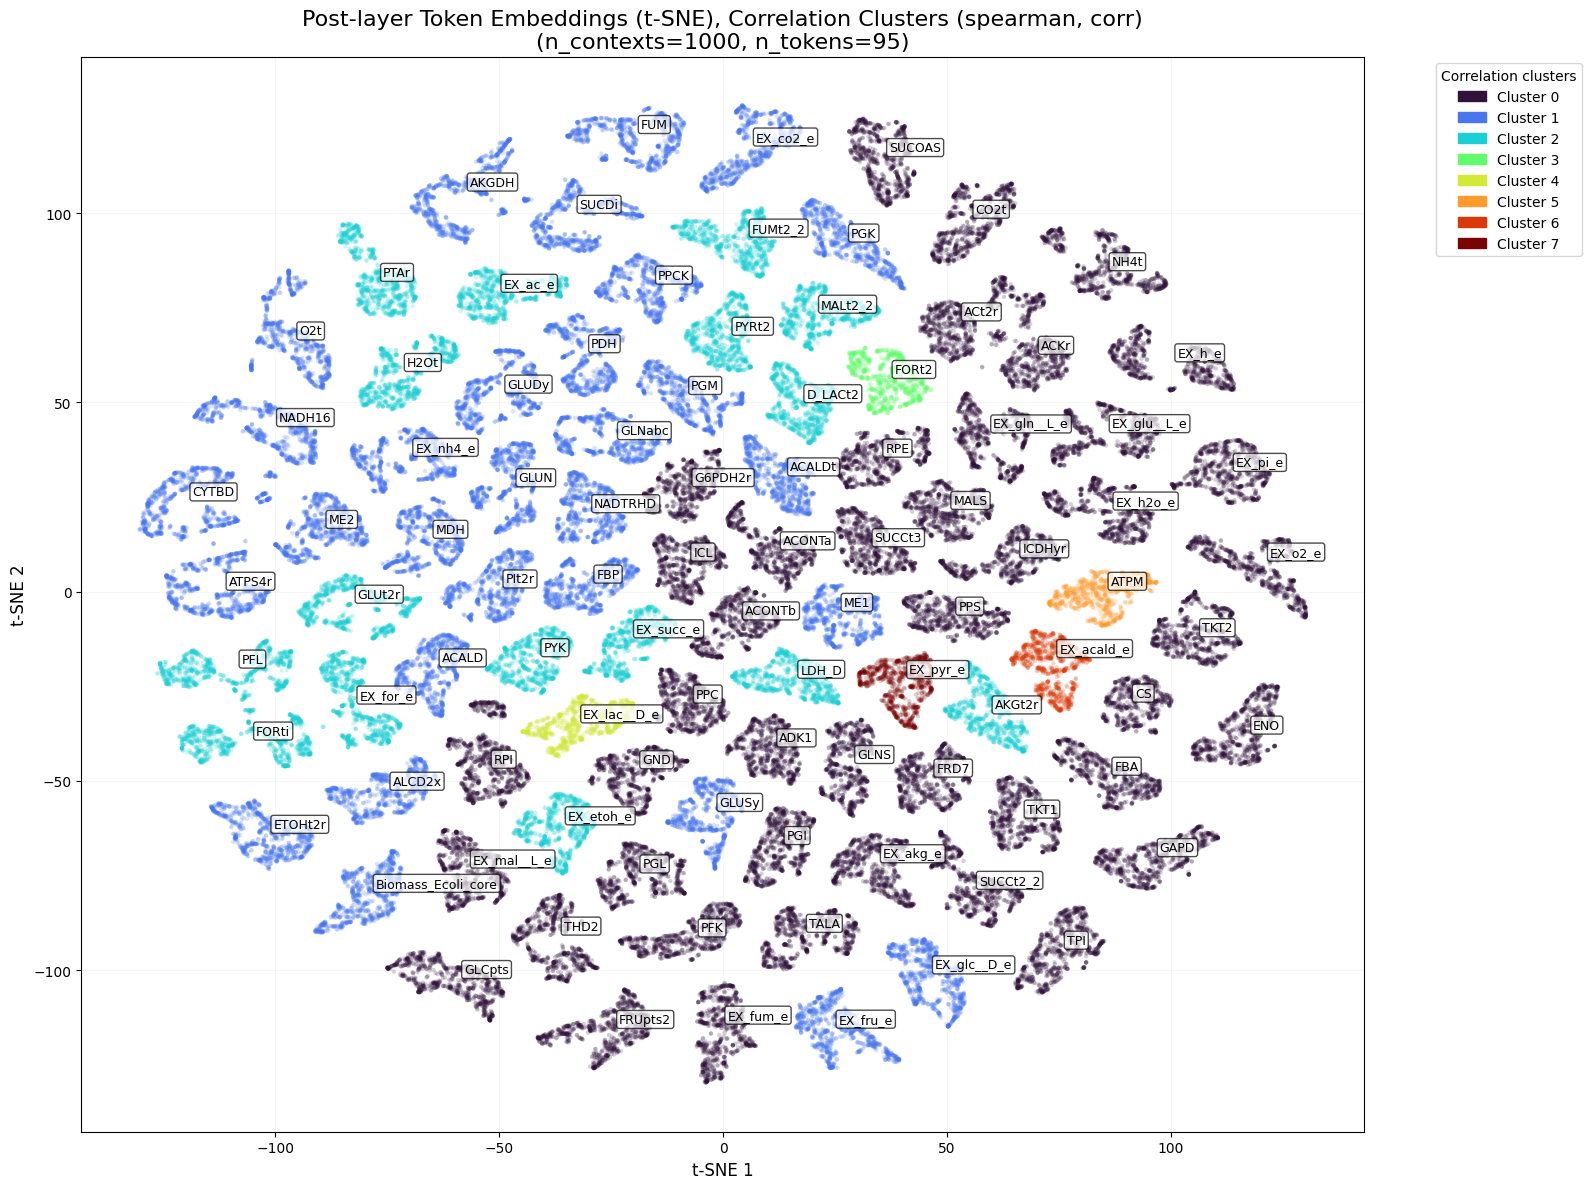

In [53]:
plot_post_attention_grouped_tsne(
    model,
    outputs,
    X_test,
    n_samples=1000,
    perplexity=30.0,
    token_indices=None,
    annotate=True,
    coloring="corr",
    corr_data_path=DATA_PATH,
    corr_n_clusters=8,           # tunable
    corr_method="spearman",      # "pearson" or "spearman"
    corr_use_abs=False,
)

c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


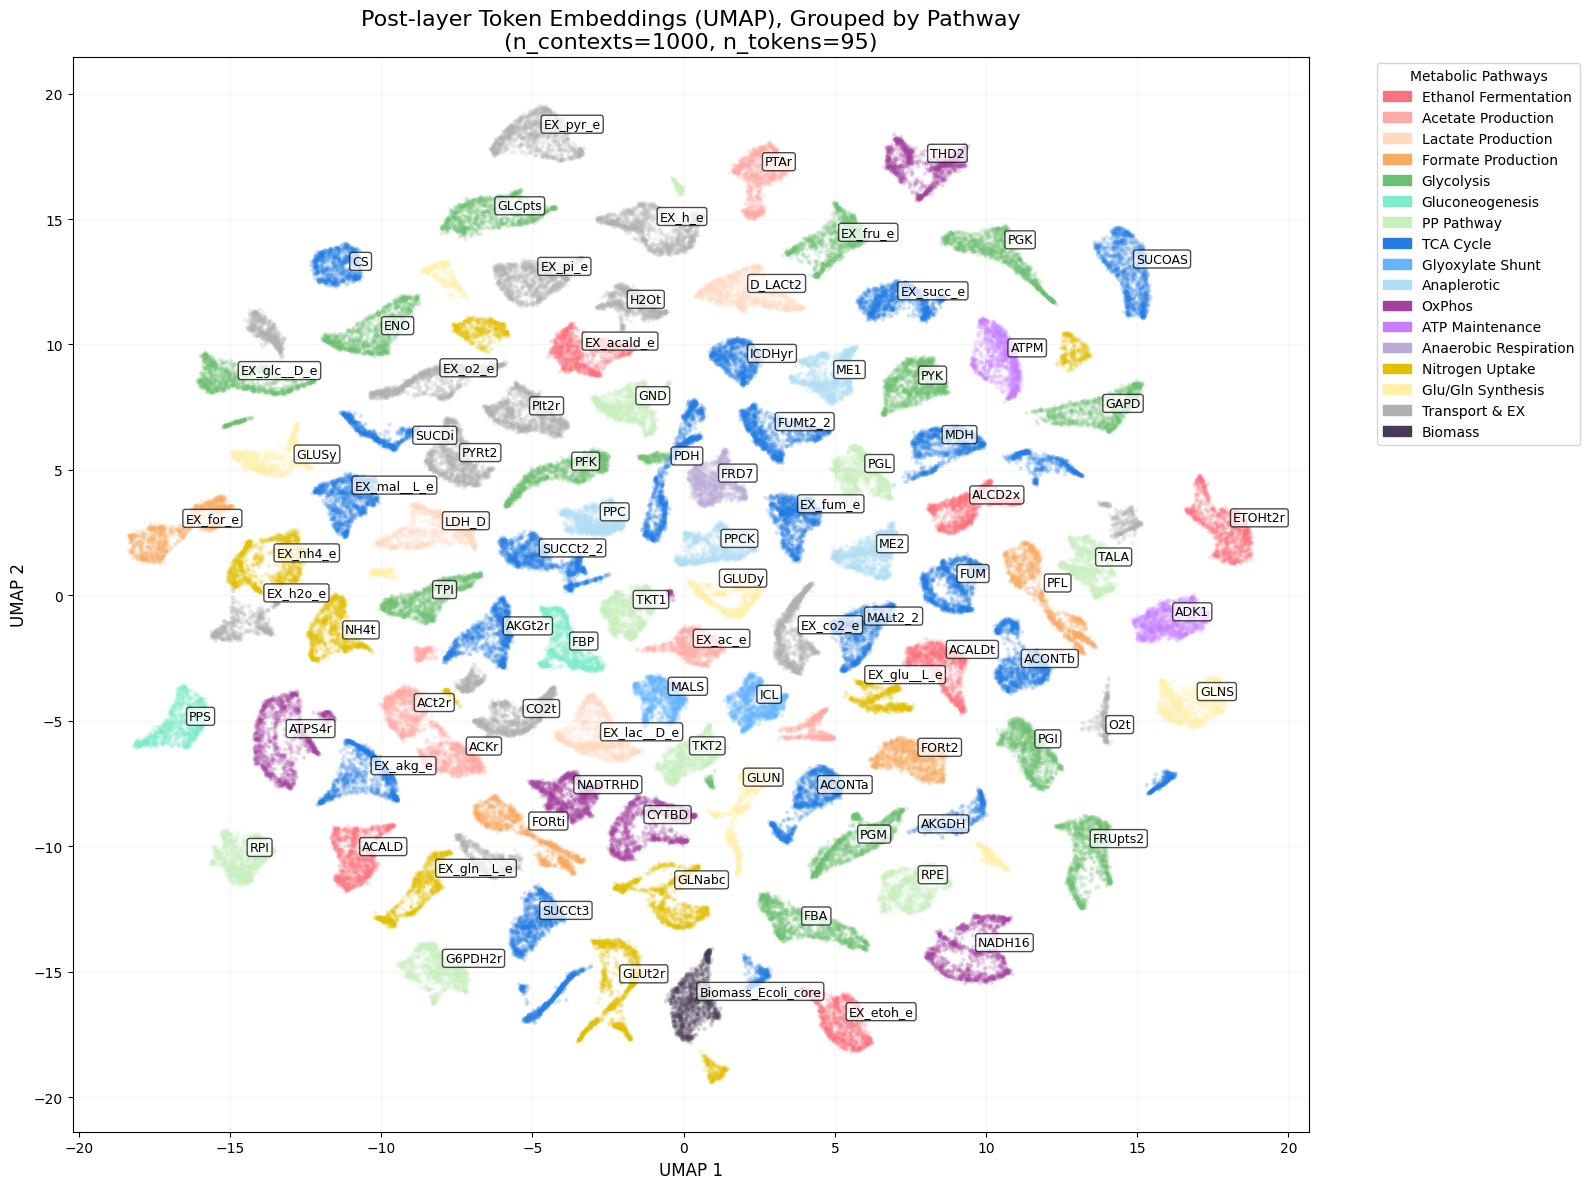

In [38]:
plot_post_attention_grouped_tsne(
    model,
    outputs,
    X_test,
    n_samples=1000,
    perplexity=30.0,
    token_indices=None,
    annotate=True,
    reducer='umap',
    n_neighbors=50,          # UMAP only
    min_dist=0.5,            # UMAP only
)

In [ ]:
# Pathway subset example
'''
idxs = [outputs.index("Biomass_Ecoli_core_flux"), outputs.index("GLUDy_flux")]
plot_post_attention_grouped_tsne(
    model,
    outputs,
    X_test,
    token_indices=idxs,
    n_samples=1000,
    perplexity=30.0,
    annotate=True
)
'''

c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


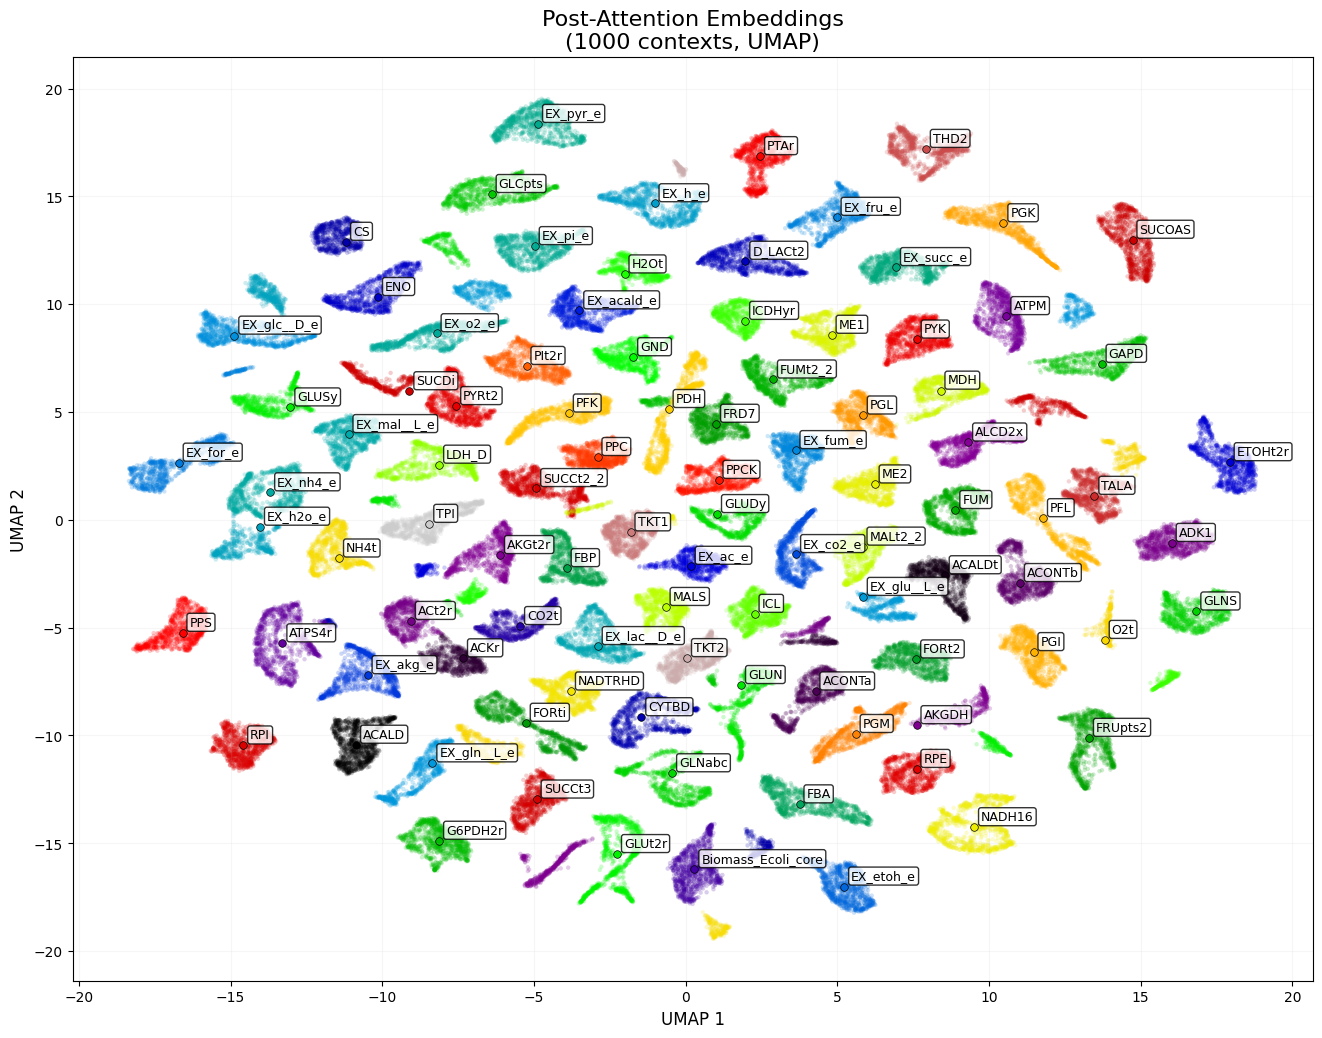

In [25]:
plot_post_attention_real_context(
    model,
    token_names=outputs,
    X_test=X_test,
    method="umap",
    n_components=2,
    n_neighbors=50, 
    min_dist=0.5
)

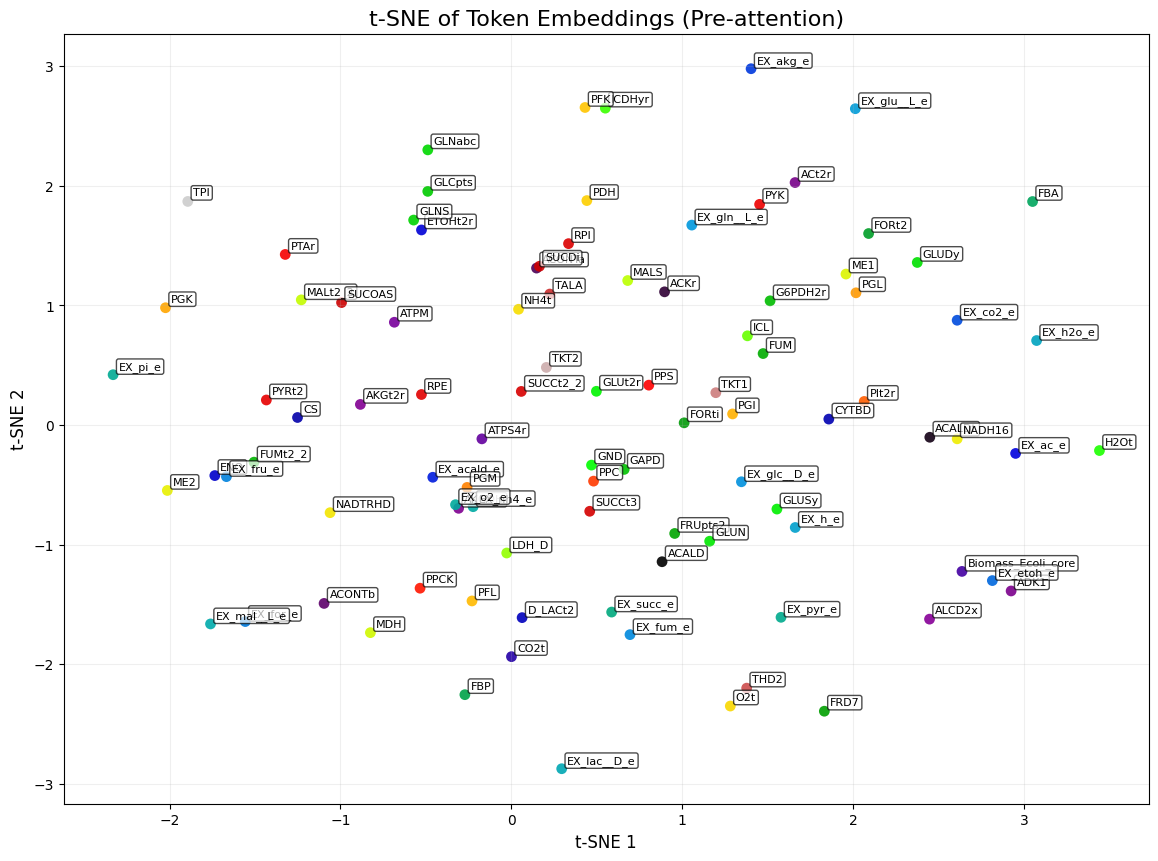

In [29]:
# pre-attention embeddings

plot_pre_attention_embeddings_tsne(
    model,
    outputs,
    perplexity=30.0,
    save_path=None,
    annotate=True
)

In [30]:
metrics = []

model_cpu = model.to("cpu").eval()

with torch.no_grad():
    preds_all_layers, _ = model_cpu(X_test.unsqueeze(-1).to("cpu"), output_subset=None)
    # preds_all_layers: (N, V, n_layers)
    y_pred_full = preds_all_layers[:, :, -1].cpu().numpy()  # (N, V)

y_true_full = y_test.cpu().numpy()  # (N, V)

# Sanity check: token names align with tensor width
V = y_true_full.shape[1]
if len(outputs) != V:
    raise ValueError(f"len(outputs)={len(outputs)} must match V={V}.")

for i, label in enumerate(outputs):
    yt = y_true_full[:, i]
    yp = y_pred_full[:, i]

    # r2 is undefined if yt is constant
    try:
        r2 = r2_score(yt, yp)
    except Exception:
        r2 = float("nan")

    mae = mean_absolute_error(yt, yp)
    metrics.append({"flux": label.replace("_flux", ""), "r2": r2, "mae": mae})

df_metrics = pd.DataFrame(metrics)[["flux", "r2", "mae"]]

df_metrics["r2"] = df_metrics["r2"].map(lambda x: "nan" if pd.isna(x) else f"{x:.3f}")
df_metrics["mae"] = df_metrics["mae"].map(lambda x: f"{x:.4f}")

print("\nModel Evaluation Metrics:\n")
display(df_metrics)


Model Evaluation Metrics:



,flux,r2,mae
0,ACALD,0.960,0.1783
1,ACALDt,0.988,0.0509
2,ACKr,0.969,0.3759
3,ACONTa,0.957,0.1338
4,ACONTb,0.957,0.1290
5,ACt2r,0.969,0.3733
6,ADK1,0.725,0.0285
7,AKGDH,0.995,0.2481
8,AKGt2r,0.990,0.0397
9,ALCD2x,0.947,0.1511


In [ ]:
ani = animate_real_context_tsne(
    model,
    outputs,
    X_test,
    n_samples=1000,
    perplexity=30.0,
    n_iter=200,
    step=1,
    gif_path=f"{pic_dir}/tsne_animation.gif",
)

Total frames collected: 101 (step=2)
Animation saved to ./pics/2026-02-08/ecoli_core_merged_d128_h8_l3_ff640/real_context_tsne.gif
